# HCSumm* / Proposed Dual-Feature Call Graph Summarization

Notebook ini menjalankan pipeline dari **file `.py`** sebagai input:

1. Baca dua file Python: `t0` dan `t1`
2. Ekstrak directed call graph
3. Visualisasi call graph dengan Graphviz
4. Ekstrak execution path
5. Hitung fitur perilaku `f(v)`
6. Bangun directed node2vec random walk dengan outgoing edge
7. Latih Word2Vec untuk mendapatkan embedding `e(v)`
8. Normalisasi `f(v)` dan `e(v)`
9. Fusion menjadi `x(v) = [e'(v) || f'(v)]`
10. Hitung Euclidean distance
11. Ward clustering
12. Bangun summary graph

Catatan: random walk node2vec di notebook ini dibuat sendiri agar **arah edge tetap dipertahankan**.

In [1]:
# Kalau dijalankan di environment baru, aktifkan cell ini.
# Di Google Colab / Jupyter, hapus tanda komentar jika package belum tersedia.

%matplotlib inline
!pip install networkx numpy scipy scikit-learn pandas graphviz pydot gensim matplotlib

In [2]:
!{sys.executable} -m pip install scipy

zsh:1: parse error near `-m'


In [3]:
import ast
import os
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from IPython.display import display, Image
from graphviz import Digraph

# from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

try:
    from gensim.models import Word2Vec
except Exception as e:
    print("Gensim belum tersedia atau bermasalah. Jalankan: pip install gensim")
    raise e

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Library loaded.")

Library loaded.


## 1. Set path file program t0 dan t1

Ganti `FILE_T0` dan `FILE_T1` sesuai lokasi file `.py` yang ingin dibandingkan.

In [4]:
# =========================
# GANTI PATH FILE DI SINI
# =========================

FILE_T0 = '/Users/lanaginting/Documents/p2mi/W3/tc1_t0.py'
FILE_T1 = '/Users/lanaginting/Documents/p2mi/W3/tc1_t1.py'

# Jumlah cluster untuk dry run / synthetic scenario
K_CLUSTERS = 2

# Parameter directed node2vec
EMBED_DIM = 4
WALK_LENGTH = 10
NUM_WALKS = 200
P_RETURN = 1.0
Q_INOUT = 1.0

print("FILE_T0:", FILE_T0)
print("FILE_T1:", FILE_T1)

FILE_T0: /Users/lanaginting/Documents/p2mi/W3/tc1_t0.py
FILE_T1: /Users/lanaginting/Documents/p2mi/W3/tc1_t1.py


## 2. Fungsi ekstraksi directed call graph dari file `.py`

Extractor ini membaca AST Python dan membangun `nx.DiGraph`.
Node = fungsi/method, edge = relasi pemanggilan fungsi.

Untuk menjaga graf tetap bersih, edge hanya ditambahkan jika callee merupakan fungsi yang didefinisikan di file yang sama.

In [5]:
class CallGraphExtractor(ast.NodeVisitor):
    def __init__(self):
        self.graph = nx.DiGraph()
        self.current_function = None
        self.defined_functions = set()

    def visit_FunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

    def visit_AsyncFunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

def _get_callee_name(call_node):
    if isinstance(call_node.func, ast.Name):
        return call_node.func.id
    if isinstance(call_node.func, ast.Attribute):
        return call_node.func.attr
    return None

class CallEdgeExtractor(ast.NodeVisitor):
    def __init__(self, graph, defined_functions):
        self.graph = graph
        self.defined_functions = defined_functions
        self.current_function = None

    def visit_FunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_AsyncFunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_Call(self, node):
        callee = _get_callee_name(node)
        if self.current_function and callee in self.defined_functions:
            self.graph.add_edge(self.current_function, callee)
        self.generic_visit(node)

def extract_call_graph_from_py(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        source = f.read()

    tree = ast.parse(source)

    node_extractor = CallGraphExtractor()
    node_extractor.visit(tree)

    edge_extractor = CallEdgeExtractor(node_extractor.graph, node_extractor.defined_functions)
    edge_extractor.visit(tree)

    return node_extractor.graph, source

print("Call graph extractor ready.")

Call graph extractor ready.


## 3. Fungsi visualisasi call graph dengan Graphviz

In [6]:
def graph_to_graphviz(G, title="Call Graph"):
    dot = Digraph(comment=title)
    dot.attr(rankdir="LR")
    dot.attr("node", shape="circle", style="filled", fillcolor="lightblue", fontname="Arial")

    for n in G.nodes():
        dot.node(str(n), str(n))

    for u, v in G.edges():
        dot.edge(str(u), str(v))

    return dot

### [TAMBAHAN VISUALISASI] ---

def graph_to_graphviz_with_clusters(G, node_to_cluster, clusters, title="Call Graph with Clusters"):
    dot = Digraph(comment=title)
    dot.attr(rankdir="TB")
    dot.attr("node", shape="circle", style="filled", fontname="Arial", fontsize="10")
    
    # Define a color palette for clusters
    colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#98D8C8", "#F7DC6F", "#BB8FCE", "#85C1E2"]
    
    # Create subgraphs for each cluster
    for cid, members in sorted(clusters.items()):
        color = colors[(cid - 1) % len(colors)]
        
        with dot.subgraph(name=f"cluster_{cid}") as subgraph:
            subgraph.attr(label=f"Cluster {cid}", style="filled", color=color, fillcolor=color, alpha="0.2")
            subgraph.attr("node", fillcolor=color, fontcolor="black")
            
            for node in members:
                subgraph.node(str(node), str(node))
    
    # Add edges from original graph
    for u, v in G.edges():
        dot.edge(str(u), str(v))
    
    return dot

### ---

def show_graph(G, filename, title="Call Graph"):
    dot = graph_to_graphviz(G, title)
    out_path = dot.render(filename, format="png", cleanup=True)
    display(Image(filename=out_path))
    return out_path

### [TAMBAHAN VISUALISASI] ---

def show_graph_with_clusters(G, node_to_cluster, clusters, filename, title="Call Graph with Clusters"):
    dot = graph_to_graphviz_with_clusters(G, node_to_cluster, clusters, title)
    out_path = dot.render(filename, format="png", cleanup=True)
    display(Image(filename=out_path))
    return out_path

### ---

print("Graphviz helpers ready.")

Graphviz helpers ready.


## 4. Baca file t0 dan t1, ekstrak call graph, dan visualisasikan

In [7]:
G_t0, source_t0 = extract_call_graph_from_py(FILE_T0)
G_t1, source_t1 = extract_call_graph_from_py(FILE_T1)

print("=== SOURCE t0 ===")
print(source_t0)
print("\n=== SOURCE t1 ===")
print(source_t1)

print("\n=== CALL GRAPH t0 ===")
print("Nodes:", list(G_t0.nodes()))
print("Edges:", list(G_t0.edges()))

print("\n=== CALL GRAPH t1 ===")
print("Nodes:", list(G_t1.nodes()))
print("Edges:", list(G_t1.edges()))

=== SOURCE t0 ===
# TC1-1: Branch Expansion (t0)
# Target: ±10-12 Nodes (Baseline)

def main():
    data = fetch_data()
    processed = process_data(data)
    save_report(processed)

def fetch_data():
    db_connect()
    return db_query()

def db_connect():
    pass # leaf

def db_query():
    pass # leaf

def process_data(d):
    d = filter_nulls(d)
    return calculate_basic_stats(d)

def filter_nulls(d):
    pass # leaf

def calculate_basic_stats(d):
    get_sum(d)
    get_avg(d)
    return d

def get_sum(d):
    pass # leaf

def get_avg(d):
    pass # leaf

def save_report(d):
    write_to_disk(d)

def write_to_disk(d):
    pass # leaf

=== SOURCE t1 ===
# TC1-1: Branch Expansion (t1)
# Target: ±20-22 Nodes (Refactored)
# Perubahan: Ekspansi cabang pada process_data

def main():
    data = fetch_data()
    processed = process_data(data)
    save_report(processed)

def fetch_data():
    db_connect()
    return db_query()

def db_connect():
    pass 

def db_query():
    pass

def p

In [8]:
# print("Visualisasi Call Graph t0")
# show_graph(G_t0, "call_graph_t0", "Call Graph t0")

# print("Visualisasi Call Graph t1")
# show_graph(G_t1, "call_graph_t1", "Call Graph t1")


# Fungsi-fungsi pipeline HCSumm* / Proposed Method

## 5. Execution path dan fitur perilaku `f(v)`

Definisi yang digunakan:
- Execution path = simple path yang mengikuti arah edge dan berakhir di exit node.
- Exit node = node dengan out-degree 0.
- Node dihitung jika dilewati path, baik sebagai node awal, tengah, maupun akhir.
- `f(v,l)` = jumlah path panjang `l` yang memuat node `v`.

In [9]:
def get_exit_nodes(G):
    return [n for n in G.nodes() if G.out_degree(n) == 0]

def extract_execution_paths(G):
    exit_nodes = get_exit_nodes(G)
    paths = []

    for start in G.nodes():
        for end in exit_nodes:
            if start == end:
                continue
            try:
                for path in nx.all_simple_paths(G, start, end):
                    if len(path) > 1:
                        paths.append(path)
            except nx.NetworkXNoPath:
                pass

    # Remove duplicates while preserving order
    seen = set()
    unique_paths = []
    for p in paths:
        key = tuple(p)
        if key not in seen:
            seen.add(key)
            unique_paths.append(p)

    return unique_paths

def build_path_length_profile(G, paths):
    if not paths:
        return {n: np.array([], dtype=float) for n in G.nodes()}, 0

    L = max(len(p) - 1 for p in paths)
    f = {n: np.zeros(L, dtype=float) for n in G.nodes()}

    for p in paths:
        length = len(p) - 1
        idx = length - 1
        for v in p:
            f[v][idx] += 1

    return f, L

def build_compact_behavior_feature_epl(G, paths):
    # 1. Hitung path-length count profile lama
    f_path, L = build_path_length_profile(G, paths)

    # 2. Hitung EPL dan EPL'
    epl = {}
    epl_norm = {}

    for v, vec in f_path.items():
        total_count = vec.sum()

        if total_count > 0 and L > 0:
            lengths = np.arange(1, L + 1)
            epl[v] = np.sum(lengths * vec) / total_count
            epl_norm[v] = epl[v] / L
        else:
            epl[v] = 0.0
            epl_norm[v] = 0.0

    # 3. Degree feature
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())

    max_indeg = max(indeg.values()) if max(indeg.values()) > 0 else 1
    max_outdeg = max(outdeg.values()) if max(outdeg.values()) > 0 else 1

    # 4. Bentuk f_star compact:
    # f*(v) = [EPL'(v), indeg'(v), outdeg'(v)]
    f_star = {}

    for v in G.nodes():
        indeg_norm = indeg[v] / max_indeg
        outdeg_norm = outdeg[v] / max_outdeg

        f_star[v] = np.array([
            epl_norm[v],
            indeg_norm,
            outdeg_norm
        ])

    return f_star, f_path, epl, epl_norm, indeg, outdeg, L

def normalize_f_l1(f):
    f_norm = {}
    for v, vec in f.items():
        s = vec.sum()
        if s > 0:
            f_norm[v] = vec / s
        else:
            f_norm[v] = vec.copy()
    return f_norm

def print_paths(paths):
    for i, p in enumerate(paths, 1):
        print(f"P{i}: {' -> '.join(map(str, p))} | length={len(p)-1}")

def features_to_dataframe(feat_dict, prefix="dim"):
    if not feat_dict:
        return pd.DataFrame()
    nodes = list(feat_dict.keys())
    max_len = max((len(v) for v in feat_dict.values()), default=0)
    data = []
    for n in nodes:
        vec = feat_dict[n]
        row = list(vec) + [np.nan] * (max_len - len(vec))
        data.append(row)
    cols = [f"{prefix}{i+1}" for i in range(max_len)]
    return pd.DataFrame(data, index=nodes, columns=cols)

def compute_node_depth(G):
    # root = semua node dengan indeg = 0
    roots = [n for n, d in G.in_degree() if d == 0]

    # inisialisasi depth
    depth = {v: float('inf') for v in G.nodes()}

    # BFS dari semua root
    from collections import deque

    queue = deque()
    for r in roots:
        depth[r] = 0
        queue.append(r)

    while queue:
        u = queue.popleft()
        for v in G.successors(u):
            if depth[v] > depth[u] + 1:
                depth[v] = depth[u] + 1
                queue.append(v)

    return depth
    
def build_compact_behavior_feature_epl(G, paths):
    import numpy as np

    # 1. Path-length profile
    f_path, L = build_path_length_profile(G, paths)

    # 2. EPL
    epl = {}
    epl_norm = {}

    for v, vec in f_path.items():
        total = vec.sum()
        if total > 0 and L > 0:
            lengths = np.arange(1, L + 1)
            epl[v] = np.sum(lengths * vec) / total
            epl_norm[v] = epl[v] / L
        else:
            epl[v] = 0.0
            epl_norm[v] = 0.0

    # 3. Degree
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())

    max_indeg = max(indeg.values()) if max(indeg.values()) > 0 else 1
    max_outdeg = max(outdeg.values()) if max(outdeg.values()) > 0 else 1

    # 4. Depth
    depth = compute_node_depth(G)
    max_depth = max([d for d in depth.values() if d < float('inf')]) if depth else 1

    depth_norm = {}
    for v in G.nodes():
        if depth[v] == float('inf'):
            depth_norm[v] = 1.0
        else:
            depth_norm[v] = depth[v] / max_depth if max_depth > 0 else 0.0

    # 5. Final f*(v)
    f_star = {}

    for v in G.nodes():
        indeg_norm = indeg[v] / max_indeg
        outdeg_norm = outdeg[v] / max_outdeg

        f_star[v] = np.array([
            epl_norm[v],
            indeg_norm,
            outdeg_norm,
            depth_norm[v]
        ])

    return f_star, f_path, epl, epl_norm, indeg, outdeg, depth, depth_norm, L

print("Execution path and f(v) functions ready.")

Execution path and f(v) functions ready.


## 6. Directed node2vec random walk

Bagian ini memastikan random walk hanya mengikuti **outgoing neighbors**.
Dengan demikian, sequence walk tetap mempertahankan arah pada call graph.

In [10]:
def directed_node2vec_walk(G, start_node, walk_length, p=1.0, q=1.0):
    walk = [start_node]

    while len(walk) < walk_length:
        curr = walk[-1]
        neighbors = list(G.successors(curr))  # penting: outgoing neighbors saja

        if len(neighbors) == 0:
            break  # exit node

        if len(walk) == 1:
            next_node = random.choice(neighbors)
        else:
            prev = walk[-2]
            weights = []

            for nbr in neighbors:
                if nbr == prev:
                    weight = 1.0 / p
                elif G.has_edge(prev, nbr) or G.has_edge(nbr, prev):
                    weight = 1.0
                else:
                    weight = 1.0 / q
                weights.append(weight)

            probs = np.array(weights, dtype=float)
            probs = probs / probs.sum()
            next_node = np.random.choice(neighbors, p=probs)

        walk.append(next_node)

    return walk

def generate_directed_node2vec_walks(G, num_walks=80, walk_length=10, p=1.0, q=1.0, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())
    walks = []

    for _ in range(num_walks):
        random.shuffle(nodes)
        for n in nodes:
            walk = directed_node2vec_walk(G, n, walk_length, p=p, q=q)
            walks.append([str(x) for x in walk])

    return walks

def compute_directed_node2vec_embedding(
    G,
    dimensions=4,
    walk_length=10,
    num_walks=200,
    p=1.0,
    q=1.0,
    seed=42,
    window=5,
    epochs=100
):
    walks = generate_directed_node2vec_walks(
        G,
        num_walks=num_walks,
        walk_length=walk_length,
        p=p,
        q=q,
        seed=seed
    )

    model = Word2Vec(
        sentences=walks,
        vector_size=dimensions,
        window=window,
        min_count=1,
        sg=1,          # skip-gram
        workers=1,
        seed=seed,
        epochs=epochs
    )

    e = {}
    for n in G.nodes():
        key = str(n)
        if key in model.wv:
            e[n] = model.wv[key]
        else:
            # fallback jika node tidak muncul dalam walk
            e[n] = np.zeros(dimensions)

    return e, walks, model

def normalize_e_l2(e):
    e_norm = {}
    for v, vec in e.items():
        norm = np.linalg.norm(vec)
        if norm > 0:
            e_norm[v] = vec / norm
        else:
            e_norm[v] = vec.copy()
    return e_norm

print("Directed node2vec functions ready.")

Directed node2vec functions ready.


## 7. Fusion, distance, Ward clustering, dan summary graph

In [11]:
def align_feature_dimensions(feat_dict, target_len):
    aligned = {}
    for n, vec in feat_dict.items():
        vec = np.asarray(vec, dtype=float)
        if len(vec) < target_len:
            vec = np.concatenate([vec, np.zeros(target_len - len(vec))])
        aligned[n] = vec
    return aligned

def fuse_features(e_norm, f_norm, alpha=1.0, beta=1.0):
    nodes = list(e_norm.keys())
    x = {}
    for n in nodes:
        x[n] = np.concatenate([alpha * e_norm[n], beta * f_norm[n]])
    return x

def compute_distance_matrix(x):
    nodes = list(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) <= 1:
        return nodes, np.zeros((len(nodes), len(nodes)))

    dist = squareform(pdist(X, metric="euclidean"))
    return nodes, dist

def ward_clustering(x, k=2):
    nodes = list(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) == 0:
        return {}, None
    if len(nodes) == 1:
        return {1: [nodes[0]]}, None

    k = min(k, len(nodes))
    Z = linkage(X, method="ward")
    labels = fcluster(Z, k, criterion="maxclust")

    clusters = {}
    for i, n in enumerate(nodes):
        clusters.setdefault(int(labels[i]), []).append(n)

    return clusters, Z

def build_summary_graph(G, clusters):
    node_to_cluster = {}
    for cid, members in clusters.items():
        for n in members:
            node_to_cluster[n] = cid

    S = nx.DiGraph()
    for cid in clusters:
        S.add_node(f"C{cid}")

    for u, v in G.edges():
        cu = node_to_cluster.get(u)
        cv = node_to_cluster.get(v)
        if cu is not None and cv is not None and cu != cv:
            S.add_edge(f"C{cu}", f"C{cv}")

    return S, node_to_cluster

def print_clusters(clusters):
    for cid, members in sorted(clusters.items()):
        print(f"C{cid}: {members}")

def visualize_clustering_iterations(Z, nodes, G, k, label="graph", max_steps=None):
    """
    Visualisasi cluster graph untuk setiap iterasi/langkah clustering.
    
    Args:
        Z: Linkage matrix dari Ward clustering
        nodes: List of original nodes
        G: NetworkX graph (call graph)
        k: Target number of final clusters
        label: Label untuk naming file output
        max_steps: Max number of steps to visualize (None = show all)
    """
    if Z is None or len(Z) == 0:
        print("Z matrix is empty or None, skipping iteration visualization")
        return
    
    num_nodes = len(nodes)
    num_merges = len(Z)
    
    # Tentukan step target untuk mendapatkan k clusters
    target_step = num_merges - k + 1
    
    # Tentukan berapa banyak step yang akan divisualisasi
    if max_steps is None:
        steps_to_show = list(range(1, num_merges + 1))
    else:
        steps_to_show = list(range(1, min(max_steps + 1, num_merges + 1)))
    
    print(f"\n{'='*80}")
    print(f"VISUALISASI CLUSTERING ITERATIONS - {label.upper()}")
    print(f"{'='*80}")
    print(f"Total nodes: {num_nodes}")
    print(f"Total merge steps: {num_merges}")
    print(f"Target step untuk {k} clusters: {target_step}")
    print(f"Steps akan divisualisasi: {len(steps_to_show)} steps\n")
    
    # Iterasi untuk setiap merge step
    for step_num in steps_to_show:
        # Rekonstruksi cluster state pada step ini
        cluster_map = {i: [nodes[i]] for i in range(num_nodes)}
        
        # Apply merges sampai step ini
        for merge_idx in range(step_num):
            c1, c2, dist, size = Z[merge_idx]
            c1, c2 = int(c1), int(c2)
            
            members_1 = cluster_map.pop(c1)  # hapus cluster lama c1
            members_2 = cluster_map.pop(c2)  # hapus cluster lama c2
            new_cluster = members_1 + members_2
            new_id = num_nodes + merge_idx
            cluster_map[new_id] = new_cluster
        
        # Build clusters dict untuk step ini
        current_clusters = {}
        cluster_id_counter = 1
        # Build clusters dict (tidak ada duplikat karena pop sudah bersihkan)
        for cluster_list in cluster_map.values():
            current_clusters[cluster_id_counter] = cluster_list
            cluster_id_counter += 1
        
        # Build node_to_cluster mapping
        node_to_cluster = {}
        for cid, members in current_clusters.items():
            for n in members:
                node_to_cluster[n] = cid
        
        # Visualisasi
        num_current_clusters = len(current_clusters)
        is_target = "✓ TARGET" if step_num == target_step else ""
        print(f"Step {step_num:2d}/{num_merges}: {num_current_clusters:2d} clusters {is_target}")
        
        # Simpan dan tampilkan
        filename = f"cluster_iter_{label}_step_{step_num:02d}"
        title = f"Cluster Graph - {label} - Step {step_num} ({num_current_clusters} clusters)"
        
        try:
            show_graph_with_clusters(G, node_to_cluster, current_clusters, filename, title)
            print(f"  → Saved as {filename}.png")
        except Exception as e:
            print(f"  ✗ Error: {e}")
        
        print()

print("Fusion, distance, clustering, and summary graph functions ready.")

Fusion, distance, clustering, and summary graph functions ready.


# Proses t0 satu per satu

## 8. t0 — Execution path

In [12]:
paths_t0 = extract_execution_paths(G_t0)
exit_t0 = get_exit_nodes(G_t0)

print("Exit nodes t0:", exit_t0)
print("\nExecution paths t0:")
print_paths(paths_t0)

Exit nodes t0: ['db_connect', 'db_query', 'filter_nulls', 'get_sum', 'get_avg', 'write_to_disk']

Execution paths t0:
P1: main -> fetch_data -> db_connect | length=2
P2: main -> fetch_data -> db_query | length=2
P3: main -> process_data -> filter_nulls | length=2
P4: main -> process_data -> calculate_basic_stats -> get_sum | length=3
P5: main -> process_data -> calculate_basic_stats -> get_avg | length=3
P6: main -> save_report -> write_to_disk | length=2
P7: fetch_data -> db_connect | length=1
P8: fetch_data -> db_query | length=1
P9: process_data -> filter_nulls | length=1
P10: process_data -> calculate_basic_stats -> get_sum | length=2
P11: process_data -> calculate_basic_stats -> get_avg | length=2
P12: calculate_basic_stats -> get_sum | length=1
P13: calculate_basic_stats -> get_avg | length=1
P14: save_report -> write_to_disk | length=1


## 9. t0 — Hitung `f(v)` dan normalisasi `f'(v)`

In [13]:
#f_t0, L_t0 = build_path_length_profile(G_t0, paths_t0)
#f_norm_t0 = normalize_f_l1(f_t0)
#f_star_t0, f_t0, f_norm_t0, indeg_t0, outdeg_t0, L_t0 = build_enriched_behavior_feature(G_t0, paths_t0)
f_star_t0, f_t0, epl_t0, epl_norm_t0, indeg_t0, outdeg_t0, depth_t0, depth_norm_t0, L_t0 = build_compact_behavior_feature_epl(G_t0, paths_t0)

print("L_t0 =", L_t0)

print("\nRaw f_path(v) t0:")
display(features_to_dataframe(f_t0, prefix="f"))

print("\nEPL(v) t0:")
display(pd.DataFrame.from_dict(epl_t0, orient="index", columns=["EPL"]))

print("\nEPL'(v) t0:")
display(pd.DataFrame.from_dict(epl_norm_t0, orient="index", columns=["EPL'"]))

print("\nIn-degree t0:")
display(pd.DataFrame.from_dict(indeg_t0, orient="index", columns=["indeg"]))

print("\nOut-degree t0:")
display(pd.DataFrame.from_dict(outdeg_t0, orient="index", columns=["outdeg"]))

print("\nDepth t0:")
display(pd.DataFrame.from_dict(depth_t0, orient="index", columns=["depth"]))

print("\nNormalized depth t0:")
display(pd.DataFrame.from_dict(depth_norm_t0, orient="index", columns=["depth'"]))

print("\nUpdated f*(v) t0:")
display(features_to_dataframe(f_star_t0, prefix="f*"))

#print("\nCompact behavior feature f*(v) t0:")
#display(features_to_dataframe(f_star_t0, prefix="f*"))

L_t0 = 3

Raw f_path(v) t0:


,f1,f2,f3
main,0.0,4.0,2.0
fetch_data,2.0,2.0,0.0
db_connect,1.0,1.0,0.0
db_query,1.0,1.0,0.0
process_data,1.0,3.0,2.0
filter_nulls,1.0,1.0,0.0
calculate_basic_stats,2.0,2.0,2.0
get_sum,1.0,1.0,1.0
get_avg,1.0,1.0,1.0
save_report,1.0,1.0,0.0



EPL(v) t0:


,EPL
main,2.333333
fetch_data,1.500000
db_connect,1.500000
db_query,1.500000
process_data,2.166667
filter_nulls,1.500000
calculate_basic_stats,2.000000
get_sum,2.000000
get_avg,2.000000
save_report,1.500000



EPL'(v) t0:


...

,depth
main,0
fetch_data,1
db_connect,2
db_query,2
process_data,1
filter_nulls,2
calculate_basic_stats,2
get_sum,3
get_avg,3
save_report,1



Normalized depth t0:


,depth'
main,0.000000
fetch_data,0.333333
db_connect,0.666667
db_query,0.666667
process_data,0.333333
filter_nulls,0.666667
calculate_basic_stats,0.666667
get_sum,1.000000
get_avg,1.000000
save_report,0.333333



Updated f*(v) t0:


,f*1,f*2,f*3,f*4
main,0.777778,0.0,1.000000,0.000000
fetch_data,0.500000,1.0,0.666667,0.333333
db_connect,0.500000,1.0,0.000000,0.666667
db_query,0.500000,1.0,0.000000,0.666667
process_data,0.722222,1.0,0.666667,0.333333
filter_nulls,0.500000,1.0,0.000000,0.666667
calculate_basic_stats,0.666667,1.0,0.666667,0.666667
get_sum,0.666667,1.0,0.000000,1.000000
get_avg,0.666667,1.0,0.000000,1.000000
save_report,0.500000,1.0,0.333333,0.333333


## 10. t0 — Directed node2vec random walk dan embedding `e(v)`

In [14]:
e_t0, walks_t0, model_t0 = compute_directed_node2vec_embedding(
    G_t0,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t0:")
for w in walks_t0[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t0:")
display(features_to_dataframe(e_t0, prefix="e"))

Contoh 10 random walks t0:
get_sum
db_query
db_connect
get_avg
filter_nulls
calculate_basic_stats -> get_avg
save_report -> write_to_disk
process_data -> filter_nulls
main -> fetch_data -> db_connect
fetch_data -> db_connect

Raw e(v) t0:


,e1,e2,e3,e4
main,-0.830784,0.649658,0.440379,-0.030824
fetch_data,-1.055861,0.504845,0.972856,-0.933001
db_connect,-0.658389,1.049211,0.259230,0.618889
db_query,-0.501559,1.168203,0.412487,0.565198
process_data,0.088594,1.523352,0.235640,0.592916
filter_nulls,-0.750877,1.105097,0.815609,0.891720
calculate_basic_stats,-0.286195,0.457987,1.775643,0.856536
get_sum,-1.001181,1.064631,0.145375,1.282882
get_avg,-0.876336,1.445149,-0.030118,1.191014
save_report,-0.738096,1.319530,0.537890,-1.304314


## 11. t0 — Normalisasi `e(v)` menjadi `e'(v)`

In [15]:
e_norm_t0 = normalize_e_l2(e_t0)

print("Normalized e'(v) t0:")
display(features_to_dataframe(e_norm_t0, prefix="e'"))

Normalized e'(v) t0:


,e'1,e'2,e'3,e'4
main,-0.726653,0.568229,0.385181,-0.026960
fetch_data,-0.591479,0.282807,0.544981,-0.522655
db_connect,-0.467361,0.744788,0.184016,0.439321
db_query,-0.345627,0.805015,0.284247,0.389481
process_data,0.053565,0.921043,0.142472,0.358487
filter_nulls,-0.416804,0.613428,0.452736,0.494985
calculate_basic_stats,-0.140012,0.224056,0.868680,0.419035
get_sum,-0.513411,0.545949,0.074549,0.657869
get_avg,-0.423799,0.698879,-0.014565,0.575978
save_report,-0.356918,0.638079,0.260105,-0.630721


## 12. t0 — Fusion menjadi `x(v)`

In [16]:
# Pastikan dimensi f(v) konsisten dengan L lokal t0
#f_norm_t0_aligned = align_feature_dimensions(f_norm_t0, L_t0)

#x_t0 = fuse_features(e_norm_t0, f_norm_t0_aligned, alpha=1.0, beta=1.0)
x_t0 = fuse_features(e_norm_t0, f_star_t0, alpha=1.0, beta=1.0)

print("Fused representation x(v) t0:")
display(features_to_dataframe(x_t0, prefix="x"))

Fused representation x(v) t0:


,x1,x2,x3,x4,x5,x6,x7,x8
main,-0.726653,0.568229,0.385181,-0.026960,0.777778,0.0,1.000000,0.000000
fetch_data,-0.591479,0.282807,0.544981,-0.522655,0.500000,1.0,0.666667,0.333333
db_connect,-0.467361,0.744788,0.184016,0.439321,0.500000,1.0,0.000000,0.666667
db_query,-0.345627,0.805015,0.284247,0.389481,0.500000,1.0,0.000000,0.666667
process_data,0.053565,0.921043,0.142472,0.358487,0.722222,1.0,0.666667,0.333333
filter_nulls,-0.416804,0.613428,0.452736,0.494985,0.500000,1.0,0.000000,0.666667
calculate_basic_stats,-0.140012,0.224056,0.868680,0.419035,0.666667,1.0,0.666667,0.666667
get_sum,-0.513411,0.545949,0.074549,0.657869,0.666667,1.0,0.000000,1.000000
get_avg,-0.423799,0.698879,-0.014565,0.575978,0.666667,1.0,0.000000,1.000000
save_report,-0.356918,0.638079,0.260105,-0.630721,0.500000,1.0,0.333333,0.333333


## 13. t0 — Euclidean distance berdasarkan `x(v)`

In [17]:
nodes_t0, dist_t0 = compute_distance_matrix(x_t0)

dist_df_t0 = pd.DataFrame(dist_t0, index=nodes_t0, columns=nodes_t0)
print("Distance matrix t0:")
display(dist_df_t0.round(4))

Distance matrix t0:


,main,fetch_data,db_connect,db_query,process_data,filter_nulls,calculate_basic_stats,get_sum,get_avg,save_report,write_to_disk
main,0.0000,1.2924,1.6964,1.7048,1.4717,1.7020,1.5695,1.9036,1.9090,1.4678,1.6422
fetch_data,1.2924,0.0000,1.3565,1.3374,1.3458,1.3189,1.1566,1.6146,1.6242,0.6206,0.8689
db_connect,1.6964,1.3565,0.0000,0.1760,0.9569,0.3084,1.1488,0.4902,0.4483,1.1818,0.9364
db_query,1.7048,1.3374,0.1760,0.0000,0.8938,0.2851,1.0929,0.5917,0.5295,1.1365,0.9734
process_data,1.4717,1.3458,0.9569,0.8938,0.0000,1.0177,1.0810,1.2035,1.1141,1.1838,1.4651
filter_nulls,1.7020,1.3189,0.3084,0.2851,1.0177,0.0000,0.9377,0.5677,0.6092,1.2372,0.9950
calculate_basic_stats,1.5695,1.1566,1.1488,1.0929,1.0810,0.9377,0.0000,1.2191,1.2909,1.3931,1.4119
get_sum,1.9036,1.6146,0.4902,0.5917,1.2035,0.5677,1.2191,0.0000,0.2146,1.5203,1.1427
get_avg,1.9090,1.6242,0.4483,0.5295,1.1141,0.6092,1.2909,0.2146,0.0000,1.4571,1.1434
save_report,1.4678,0.6206,1.1818,1.1365,1.1838,1.2372,1.3931,1.5203,1.4571,0.0000,0.7488


## 14. t0 — Ward clustering

In [18]:
clusters_t0, Z_t0 = ward_clustering(x_t0, k=K_CLUSTERS)

print("Clusters t0:")
print_clusters(clusters_t0)

if Z_t0 is not None:
    print("\nWard linkage matrix t0:")
    display(pd.DataFrame(Z_t0, columns=["cluster_1", "cluster_2", "distance", "size"]))

def explain_ward_merges(Z, nodes):
    cluster_map = {i: [nodes[i]] for i in range(len(nodes))}

    print("\nUrutan merge Ward clustering:")
    for step, row in enumerate(Z, start=1):
        c1, c2, dist, size = row
        c1 = int(c1)
        c2 = int(c2)

        members_1 = cluster_map[c1]
        members_2 = cluster_map[c2]

        new_cluster = members_1 + members_2
        new_id = len(nodes) + step - 1
        cluster_map[new_id] = new_cluster

        print(f"Iterasi {step}: merge {members_1} + {members_2} -> {new_cluster}")
        print(f"  linkage distance = {dist:.4f}, size = {int(size)}")

if Z_t0 is not None:
    explain_ward_merges(Z_t0, list(x_t0.keys()))

# # ===== VISUALISASI CLUSTER GRAPH UNTUK SETIAP ITERASI - t0 =====
# if Z_t0 is not None:
#     visualize_clustering_iterations(Z_t0, list(x_t0.keys()), G_t0, K_CLUSTERS, label="t0")

Clusters t0:
C1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg']
C2: ['main', 'fetch_data', 'save_report', 'write_to_disk']

Ward linkage matrix t0:


,cluster_1,cluster_2,distance,size
0,2.0,3.0,0.176002,2.0
1,7.0,8.0,0.214628,2.0
2,5.0,11.0,0.327539,3.0
3,1.0,9.0,0.620629,2.0
4,12.0,13.0,0.789414,5.0
5,10.0,14.0,0.865248,3.0
6,4.0,6.0,1.080974,2.0
7,15.0,17.0,1.535942,7.0
8,0.0,16.0,1.725498,4.0
9,18.0,19.0,2.443704,11.0



Urutan merge Ward clustering:
Iterasi 1: merge ['db_connect'] + ['db_query'] -> ['db_connect', 'db_query']
  linkage distance = 0.1760, size = 2
Iterasi 2: merge ['get_sum'] + ['get_avg'] -> ['get_sum', 'get_avg']
  linkage distance = 0.2146, size = 2
Iterasi 3: merge ['filter_nulls'] + ['db_connect', 'db_query'] -> ['filter_nulls', 'db_connect', 'db_query']
  linkage distance = 0.3275, size = 3
Iterasi 4: merge ['fetch_data'] + ['save_report'] -> ['fetch_data', 'save_report']
  linkage distance = 0.6206, size = 2
Iterasi 5: merge ['get_sum', 'get_avg'] + ['filter_nulls', 'db_connect', 'db_query'] -> ['get_sum', 'get_avg', 'filter_nulls', 'db_connect', 'db_query']
  linkage distance = 0.7894, size = 5
Iterasi 6: merge ['write_to_disk'] + ['fetch_data', 'save_report'] -> ['write_to_disk', 'fetch_data', 'save_report']
  linkage distance = 0.8652, size = 3
Iterasi 7: merge ['process_data'] + ['calculate_basic_stats'] -> ['process_data', 'calculate_basic_stats']
  linkage distance = 1.081

## 15. t0 — Summary graph

In [19]:
S_t0, node_to_cluster_t0 = build_summary_graph(G_t0, clusters_t0)

print("Node to cluster mapping t0:")
print(node_to_cluster_t0)

print("\nSummary graph edges t0:")
print(list(S_t0.edges()))

# print("\nVisualisasi Summary Graph t0 (Original Call Graph with Cluster Colors)")
# show_graph_with_clusters(G_t0, node_to_cluster_t0, clusters_t0, "summary_graph_t0", "Call Graph with Clusters - t0")

# print("\nVisualisasi Summary Graph t0 (Cluster-only View)")
# show_graph(S_t0, "summary_graph_t0_clusters_only", "Summary Graph t0 (Clusters Only)")


Node to cluster mapping t0:
{'main': 2, 'fetch_data': 2, 'save_report': 2, 'write_to_disk': 2, 'db_connect': 1, 'db_query': 1, 'process_data': 1, 'filter_nulls': 1, 'calculate_basic_stats': 1, 'get_sum': 1, 'get_avg': 1}

Summary graph edges t0:
[('C2', 'C1')]


# Proses t1 satu per satu

## 16. t1 — Execution path

In [20]:
paths_t1 = extract_execution_paths(G_t1)
exit_t1 = get_exit_nodes(G_t1)

print("Exit nodes t1:", exit_t1)
print("\nExecution paths t1:")
print_paths(paths_t1)

Exit nodes t1: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'apply_linear_model', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'write_to_disk']

Execution paths t1:
P1: main -> fetch_data -> db_connect | length=2
P2: main -> fetch_data -> db_query | length=2
P3: main -> process_data -> run_advanced_analytics -> detect_anomalies -> check_outliers | length=4
P4: main -> process_data -> run_advanced_analytics -> detect_anomalies -> log_anomaly_report | length=4
P5: main -> process_data -> run_advanced_analytics -> predict_future_trends -> apply_linear_model | length=4
P6: main -> process_data -> run_advanced_analytics -> generate_meta_summary -> format_table_output | length=4
P7: main -> process_data -> filter_nulls | length=2
P8: main -> process_data -> calculate_basic_stats -> get_sum | length=3
P9: main -> process_data -> calculate_basic_stats -> get_avg | length=3
P10: main -> save_report -> write_to_disk | length=2
P11: fetch_data -> db_connect |

## 17. t1 — Hitung `f(v)` dan normalisasi `f'(v)`

In [21]:
#f_t1, L_t1 = build_path_length_profile(G_t1, paths_t1)
#f_norm_t1 = normalize_f_l1(f_t1)

f_star_t1, f_t1, epl_t1, epl_norm_t1, indeg_t1, outdeg_t1, depth_t1, depth_norm_t1, L_t1 = build_compact_behavior_feature_epl(G_t1, paths_t1)

print("L_t1 =", L_t1)

print("\nRaw f_path(v) t1:")
display(features_to_dataframe(f_t1, prefix="f"))

print("\nEPL(v) t1:")
display(pd.DataFrame.from_dict(epl_t1, orient="index", columns=["EPL"]))

print("\nEPL'(v) t1:")
display(pd.DataFrame.from_dict(epl_norm_t1, orient="index", columns=["EPL'"]))

print("\nIn-degree t1:")
display(pd.DataFrame.from_dict(indeg_t1, orient="index", columns=["indeg"]))

print("\nOut-degree t1:")
display(pd.DataFrame.from_dict(outdeg_t1, orient="index", columns=["outdeg"]))

print("\nDepth t1:")
display(pd.DataFrame.from_dict(depth_t1, orient="index", columns=["depth"]))

print("\nNormalized depth t1:")
display(pd.DataFrame.from_dict(depth_norm_t1, orient="index", columns=["depth'"]))

print("\nUpdated f*(v) t1:")
display(features_to_dataframe(f_star_t1, prefix="f*"))

L_t1 = 4

Raw f_path(v) t1:


,f1,f2,f3,f4
main,0.0,4.0,2.0,4.0
fetch_data,2.0,2.0,0.0,0.0
db_connect,1.0,1.0,0.0,0.0
db_query,1.0,1.0,0.0,0.0
process_data,1.0,3.0,6.0,4.0
run_advanced_analytics,0.0,4.0,4.0,4.0
detect_anomalies,2.0,2.0,2.0,2.0
check_outliers,1.0,1.0,1.0,1.0
log_anomaly_report,1.0,1.0,1.0,1.0
predict_future_trends,1.0,1.0,1.0,1.0



EPL(v) t1:


,EPL
main,3.000000
fetch_data,1.500000
db_connect,1.500000
db_query,1.500000
process_data,2.928571
run_advanced_analytics,3.000000
detect_anomalies,2.500000
check_outliers,2.500000
log_anomaly_report,2.500000
predict_future_trends,2.500000



EPL'(v) t1:


...

,depth
main,0
fetch_data,1
db_connect,2
db_query,2
process_data,1
run_advanced_analytics,2
detect_anomalies,3
check_outliers,4
log_anomaly_report,4
predict_future_trends,3



Normalized depth t1:


,depth'
main,0.00
fetch_data,0.25
db_connect,0.50
db_query,0.50
process_data,0.25
run_advanced_analytics,0.50
detect_anomalies,0.75
check_outliers,1.00
log_anomaly_report,1.00
predict_future_trends,0.75



Updated f*(v) t1:


,f*1,f*2,f*3,f*4
main,0.750000,0.0,1.000000,0.00
fetch_data,0.375000,1.0,0.666667,0.25
db_connect,0.375000,1.0,0.000000,0.50
db_query,0.375000,1.0,0.000000,0.50
process_data,0.732143,1.0,1.000000,0.25
run_advanced_analytics,0.750000,1.0,1.000000,0.50
detect_anomalies,0.625000,1.0,0.666667,0.75
check_outliers,0.625000,1.0,0.000000,1.00
log_anomaly_report,0.625000,1.0,0.000000,1.00
predict_future_trends,0.625000,1.0,0.333333,0.75


## 18. t1 — Directed node2vec random walk dan embedding `e(v)`

In [22]:
e_t1, walks_t1, model_t1 = compute_directed_node2vec_embedding(
    G_t1,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t1:")
for w in walks_t1[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t1:")
display(features_to_dataframe(e_t1, prefix="e"))

Contoh 10 random walks t1:
calculate_basic_stats -> get_sum
filter_nulls
process_data -> calculate_basic_stats -> get_sum
predict_future_trends -> apply_linear_model
run_advanced_analytics -> detect_anomalies -> log_anomaly_report
get_sum
save_report -> write_to_disk
detect_anomalies -> log_anomaly_report
format_table_output
get_avg

Raw e(v) t1:


,e1,e2,e3,e4
main,-0.768841,-0.523897,0.838892,0.421327
fetch_data,-0.041046,0.486864,2.539925,2.544520
db_connect,-0.873222,-1.054696,2.179744,0.229326
db_query,-0.816852,-1.141123,2.324748,0.376800
process_data,-0.634675,0.339499,0.695056,-0.081404
run_advanced_analytics,-1.050059,1.198766,0.529605,-0.363666
detect_anomalies,-0.147444,2.603085,1.858477,0.252960
check_outliers,-1.410791,1.170526,0.524716,0.691971
log_anomaly_report,-1.278329,1.181049,0.594223,0.784737
predict_future_trends,0.132601,0.566228,1.947373,-0.316209


## 19. t1 — Normalisasi `e(v)` menjadi `e'(v)`

In [23]:
e_norm_t1 = normalize_e_l2(e_t1)

print("Normalized e'(v) t1:")
display(features_to_dataframe(e_norm_t1, prefix="e'"))

Normalized e'(v) t1:


,e'1,e'2,e'3,e'4
main,-0.581715,-0.396387,0.634716,0.318781
fetch_data,-0.011313,0.134185,0.700033,0.701299
db_connect,-0.337891,-0.408112,0.843445,0.088737
db_query,-0.297958,-0.416240,0.847983,0.137443
process_data,-0.632214,0.338182,0.692361,-0.081088
run_advanced_analytics,-0.611120,0.697665,0.308223,-0.211649
detect_anomalies,-0.045907,0.810473,0.578639,0.078759
check_outliers,-0.695502,0.577054,0.258678,0.341133
log_anomaly_report,-0.639331,0.590678,0.297189,0.392471
predict_future_trends,0.064469,0.275295,0.946795,-0.153738


## 20. t1 — Fusion menjadi `x(v)`

In [24]:
x_t1 = fuse_features(e_norm_t1, f_star_t1, alpha=1.0, beta=1.0)

print("Fused representation x(v) t1:")
display(features_to_dataframe(x_t1, prefix="x"))

Fused representation x(v) t1:


,x1,x2,x3,x4,x5,x6,x7,x8
main,-0.581715,-0.396387,0.634716,0.318781,0.750000,0.0,1.000000,0.00
fetch_data,-0.011313,0.134185,0.700033,0.701299,0.375000,1.0,0.666667,0.25
db_connect,-0.337891,-0.408112,0.843445,0.088737,0.375000,1.0,0.000000,0.50
db_query,-0.297958,-0.416240,0.847983,0.137443,0.375000,1.0,0.000000,0.50
process_data,-0.632214,0.338182,0.692361,-0.081088,0.732143,1.0,1.000000,0.25
run_advanced_analytics,-0.611120,0.697665,0.308223,-0.211649,0.750000,1.0,1.000000,0.50
detect_anomalies,-0.045907,0.810473,0.578639,0.078759,0.625000,1.0,0.666667,0.75
check_outliers,-0.695502,0.577054,0.258678,0.341133,0.625000,1.0,0.000000,1.00
log_anomaly_report,-0.639331,0.590678,0.297189,0.392471,0.625000,1.0,0.000000,1.00
predict_future_trends,0.064469,0.275295,0.946795,-0.153738,0.625000,1.0,0.333333,0.75


## 21. t1 — Euclidean distance berdasarkan `x(v)`

In [25]:
nodes_t1, dist_t1 = compute_distance_matrix(x_t1)

dist_df_t1 = pd.DataFrame(dist_t1, index=nodes_t1, columns=nodes_t1)
print("Distance matrix t1:")
display(dist_df_t1.round(4))

Distance matrix t1:


,main,fetch_data,db_connect,db_query,process_data,run_advanced_analytics,detect_anomalies,check_outliers,log_anomaly_report,predict_future_trends,apply_linear_model,generate_meta_summary,format_table_output,filter_nulls,calculate_basic_stats,get_sum,get_avg,save_report,write_to_disk
main,0.0000,1.4393,1.5958,1.5968,1.3297,1.6840,1.8691,2.0293,2.0280,1.7922,2.1105,1.9007,2.0775,1.7518,1.5261,1.8171,1.8113,1.4357,1.5944
fetch_data,1.4393,0.0000,1.1417,1.1099,1.1305,1.4066,1.0832,1.4346,1.3892,1.1141,1.5994,1.5598,1.7985,1.1982,0.8980,1.3782,1.3785,1.3964,1.1724
db_connect,1.5958,1.1417,0.0000,0.0637,1.3731,1.6777,1.4866,1.3478,1.3385,0.9667,1.4925,1.2587,1.3368,0.8278,1.3971,0.5983,0.5825,0.7634,0.7632
db_query,1.5968,1.1099,0.0637,0.0000,1.3939,1.7008,1.4879,1.3587,1.3459,0.9697,1.5090,1.2965,1.3765,0.8576,1.3911,0.6327,0.6172,0.8098,0.7578
process_data,1.3297,1.1305,1.3731,1.3939,0.0000,0.5976,0.9889,1.4147,1.4206,1.1248,1.4855,1.0252,1.4035,1.0931,1.0907,1.3104,1.3167,1.1265,1.4934
run_advanced_analytics,1.6840,1.4066,1.6777,1.7008,0.5976,0.0000,0.8239,1.2631,1.2818,1.2524,1.2496,0.8825,1.2211,1.2064,1.1083,1.4909,1.5021,1.4080,1.6965
detect_anomalies,1.8691,1.0832,1.4866,1.4879,0.9889,0.8239,0.0000,1.0745,1.0417,0.7741,1.1783,0.9252,1.3157,1.0631,1.1318,1.2524,1.2673,1.5997,1.6314
check_outliers,2.0293,1.4346,1.3478,1.3587,1.4147,1.2631,1.0745,0.0000,0.0864,1.2493,0.2800,1.0781,0.7715,0.8344,0.9761,1.2454,1.2544,1.4895,1.1307
log_anomaly_report,2.0280,1.3892,1.3385,1.3459,1.4206,1.2818,1.0417,0.0864,0.0000,1.2201,0.3514,1.1062,0.8400,0.8386,0.9648,1.2432,1.2524,1.5173,1.1329
predict_future_trends,1.7922,1.1141,0.9667,0.9697,1.1248,1.2524,0.7741,1.2493,1.2201,0.0000,1.4016,0.8381,1.2825,0.8848,1.4462,0.6251,0.6378,1.2817,1.4412


## 22. t1 — Ward clustering

In [26]:
clusters_t1, Z_t1 = ward_clustering(x_t1, k=K_CLUSTERS)

print("Clusters t1:")
print_clusters(clusters_t1)

if Z_t1 is not None:
    print("\nWard linkage matrix t1:")
    display(pd.DataFrame(Z_t1, columns=["cluster_1", "cluster_2", "distance", "size"]))

if Z_t1 is not None:
    explain_ward_merges(Z_t1, list(x_t1.keys()))

# ===== VISUALISASI CLUSTER GRAPH UNTUK SETIAP ITERASI - t1 =====
# if Z_t1 is not None:
#     visualize_clustering_iterations(Z_t1, list(x_t1.keys()), G_t1, K_CLUSTERS, label="t1")

Clusters t1:
C1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats']
C2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']

Ward linkage matrix t1:


,cluster_1,cluster_2,distance,size
0,15.0,16.0,0.023566,2.0
1,2.0,3.0,0.063667,2.0
2,7.0,8.0,0.086368,2.0
3,10.0,21.0,0.363490,3.0
4,4.0,5.0,0.597578,2.0
5,11.0,12.0,0.694280,2.0
6,9.0,19.0,0.729061,3.0
7,18.0,20.0,0.877383,3.0
8,13.0,24.0,0.885607,3.0
9,1.0,14.0,0.897980,2.0



Urutan merge Ward clustering:
Iterasi 1: merge ['get_sum'] + ['get_avg'] -> ['get_sum', 'get_avg']
  linkage distance = 0.0236, size = 2
Iterasi 2: merge ['db_connect'] + ['db_query'] -> ['db_connect', 'db_query']
  linkage distance = 0.0637, size = 2
Iterasi 3: merge ['check_outliers'] + ['log_anomaly_report'] -> ['check_outliers', 'log_anomaly_report']
  linkage distance = 0.0864, size = 2
Iterasi 4: merge ['apply_linear_model'] + ['check_outliers', 'log_anomaly_report'] -> ['apply_linear_model', 'check_outliers', 'log_anomaly_report']
  linkage distance = 0.3635, size = 3
Iterasi 5: merge ['process_data'] + ['run_advanced_analytics'] -> ['process_data', 'run_advanced_analytics']
  linkage distance = 0.5976, size = 2
Iterasi 6: merge ['generate_meta_summary'] + ['format_table_output'] -> ['generate_meta_summary', 'format_table_output']
  linkage distance = 0.6943, size = 2
Iterasi 7: merge ['predict_future_trends'] + ['get_sum', 'get_avg'] -> ['predict_future_trends', 'get_sum', 'ge

## 23. t1 — Summary graph

In [27]:
S_t1, node_to_cluster_t1 = build_summary_graph(G_t1, clusters_t1)

print("Node to cluster mapping t1:")
print(node_to_cluster_t1)

print("\nSummary graph edges t1:")
print(list(S_t1.edges()))

# print("\nVisualisasi Summary Graph t1 (Original Call Graph with Cluster Colors)")
# show_graph_with_clusters(G_t1, node_to_cluster_t1, clusters_t1, "summary_graph_t1", "Call Graph with Clusters - t1")

# print("\nVisualisasi Summary Graph t1 (Cluster-only View)")
# show_graph(S_t1, "summary_graph_t1_clusters_only", "Summary Graph t1 (Clusters Only)")


Node to cluster mapping t1:
{'main': 1, 'fetch_data': 1, 'process_data': 1, 'run_advanced_analytics': 1, 'detect_anomalies': 1, 'calculate_basic_stats': 1, 'db_connect': 2, 'db_query': 2, 'check_outliers': 2, 'log_anomaly_report': 2, 'predict_future_trends': 2, 'apply_linear_model': 2, 'generate_meta_summary': 2, 'format_table_output': 2, 'filter_nulls': 2, 'get_sum': 2, 'get_avg': 2, 'save_report': 2, 'write_to_disk': 2}

Summary graph edges t1:
[('C1', 'C2')]


# 24. Rekap hasil t0 vs t1

In [28]:
recap = pd.DataFrame([
    {
        "version": "t0",
        "nodes": G_t0.number_of_nodes(),
        "edges": G_t0.number_of_edges(),
        "exit_nodes": exit_t0,
        "num_paths": len(paths_t0),
        "L": L_t0,
        "clusters": clusters_t0,
        "summary_edges": list(S_t0.edges())
    },
    {
        "version": "t1",
        "nodes": G_t1.number_of_nodes(),
        "edges": G_t1.number_of_edges(),
        "exit_nodes": exit_t1,
        "num_paths": len(paths_t1),
        "L": L_t1,
        "clusters": clusters_t1,
        "summary_edges": list(S_t1.edges())
    }
])

display(recap)

,version,nodes,edges,exit_nodes,num_paths,L,clusters,summary_edges
0,t0,11,10,"[db_connect, db_query, filter_nulls, get_sum, ...",14,3,"{2: ['main', 'fetch_data', 'save_report', 'wri...","[(C2, C1)]"
1,t1,19,18,"[db_connect, db_query, check_outliers, log_ano...",30,4,"{1: ['main', 'fetch_data', 'process_data', 'ru...","[(C1, C2)]"


---
# Isolasi Parameter Node2Vec — 19 Eksperimen

Metode: **OFAT (One Factor At A Time)** — satu parameter diubah, sisanya dikunci ke baseline.

| No | Parameter | Baseline |
|---|---|---|
| A | `EMBED_DIM` | 4 |
| B | `WALK_LENGTH` | 10 |
| C | `NUM_WALKS` | 200 |
| D | `P_RETURN` | 1.0 |
| E | `Q_INOUT` | 1.0 |

Output tiap eksperimen: cluster t0, cluster t1, jarak rata-rata intra-cluster t0 & t1.


No  Label                        Clusters t0                         Clusters t1                         IntraDist t0 IntraDist t1
----------------------------------------------------------------------------------------------------------------------------------
1   01 — Baseline                {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 1: 01 — Baseline
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_av

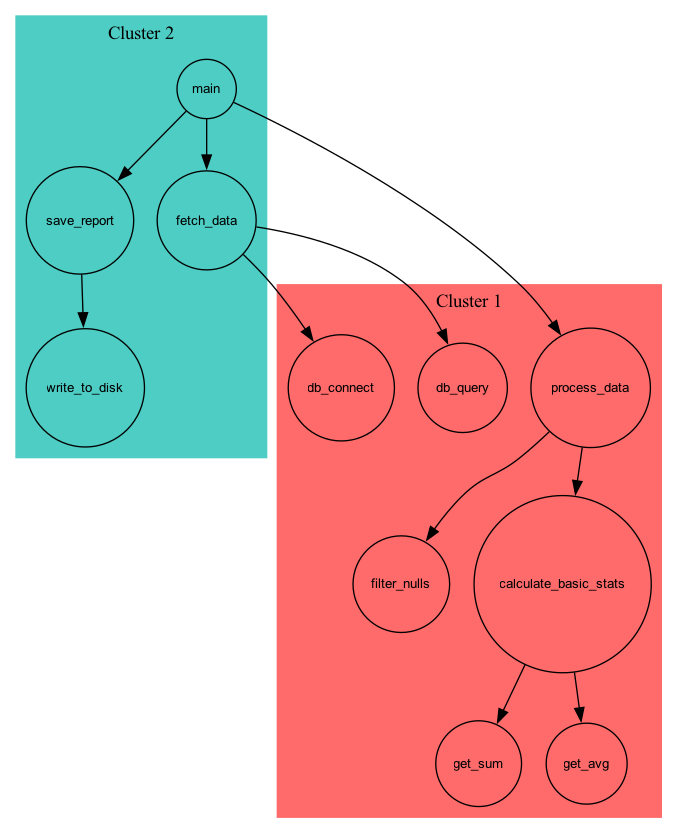

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


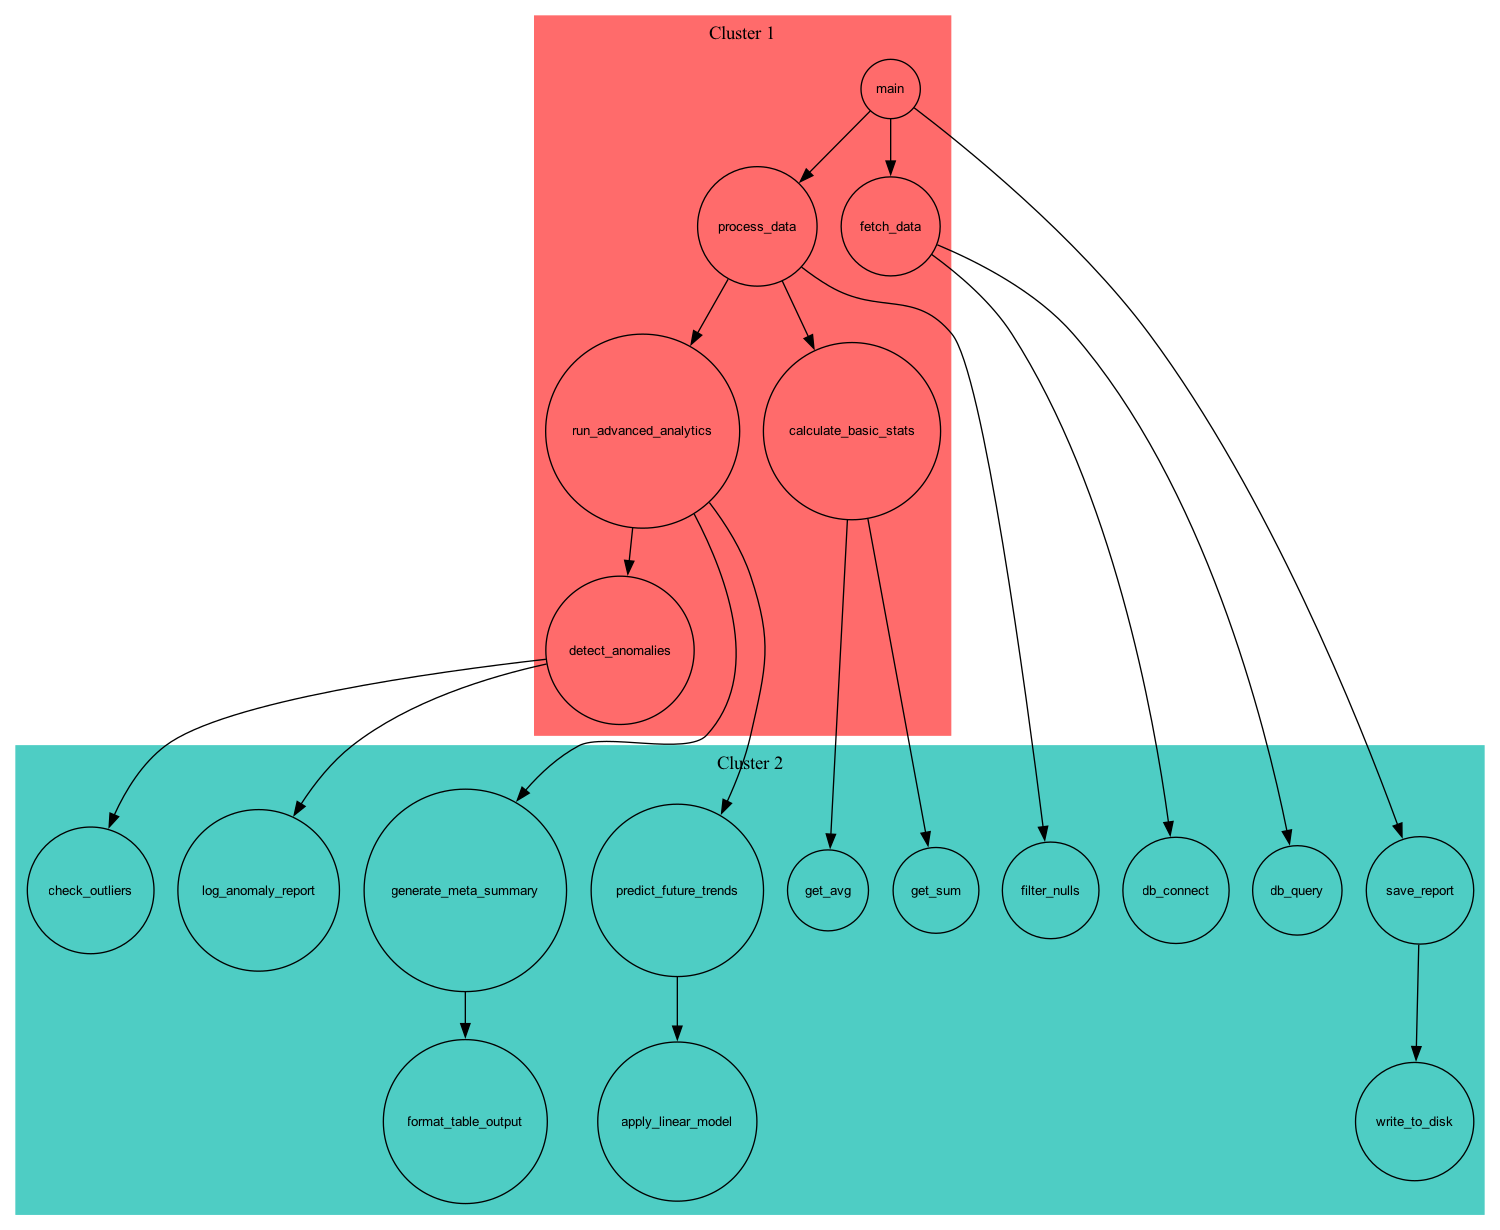


2   02 — A: EMBED_DIM=2          {2: ['calculate_basic_stats', 'fetch_data', 'main', 'process_data'], 1: ['db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'save_report', 'write_to_disk']} {2: ['apply_linear_model', 'calculate_basic_stats', 'check_outliers', 'detect_anomalies', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'main', 'predict_future_trends', 'process_data', 'run_advanced_analytics'], 1: ['db_connect', 'db_query', 'fetch_data', 'filter_nulls', 'save_report', 'write_to_disk']}     0.618123     0.764839

  ▶ Eksperimen 2: 02 — A: EMBED_DIM=2
    [t0] Clusters: {1: ['db_connect', 'db_query', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk'], 2: ['main', 'fetch_data', 'process_data', 'calculate_basic_stats']}


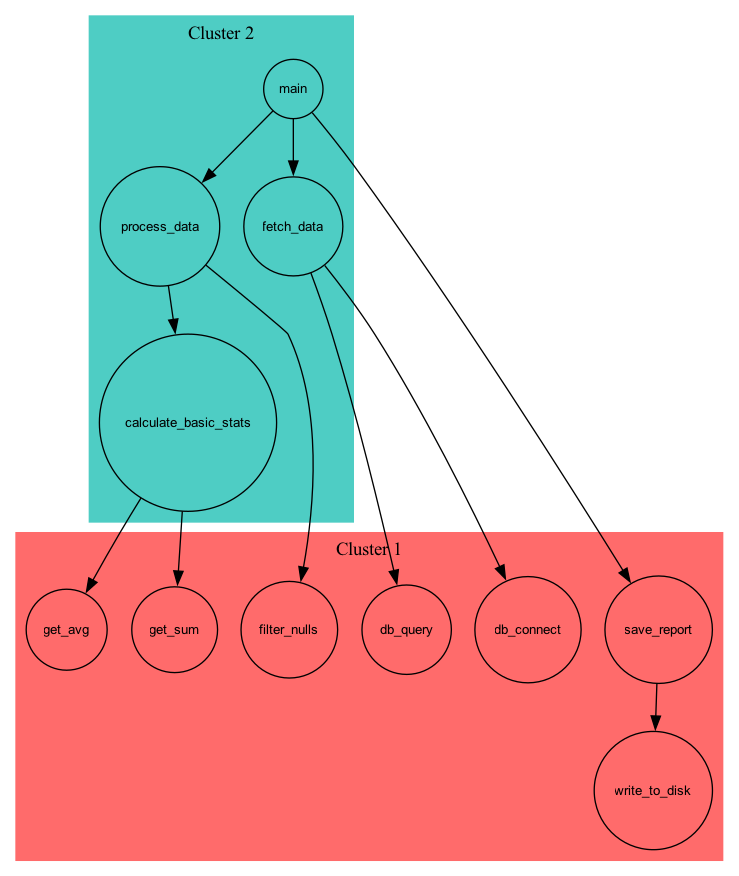

    [t1] Clusters: {1: ['fetch_data', 'db_connect', 'db_query', 'filter_nulls', 'save_report', 'write_to_disk'], 2: ['main', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'calculate_basic_stats', 'get_sum', 'get_avg']}


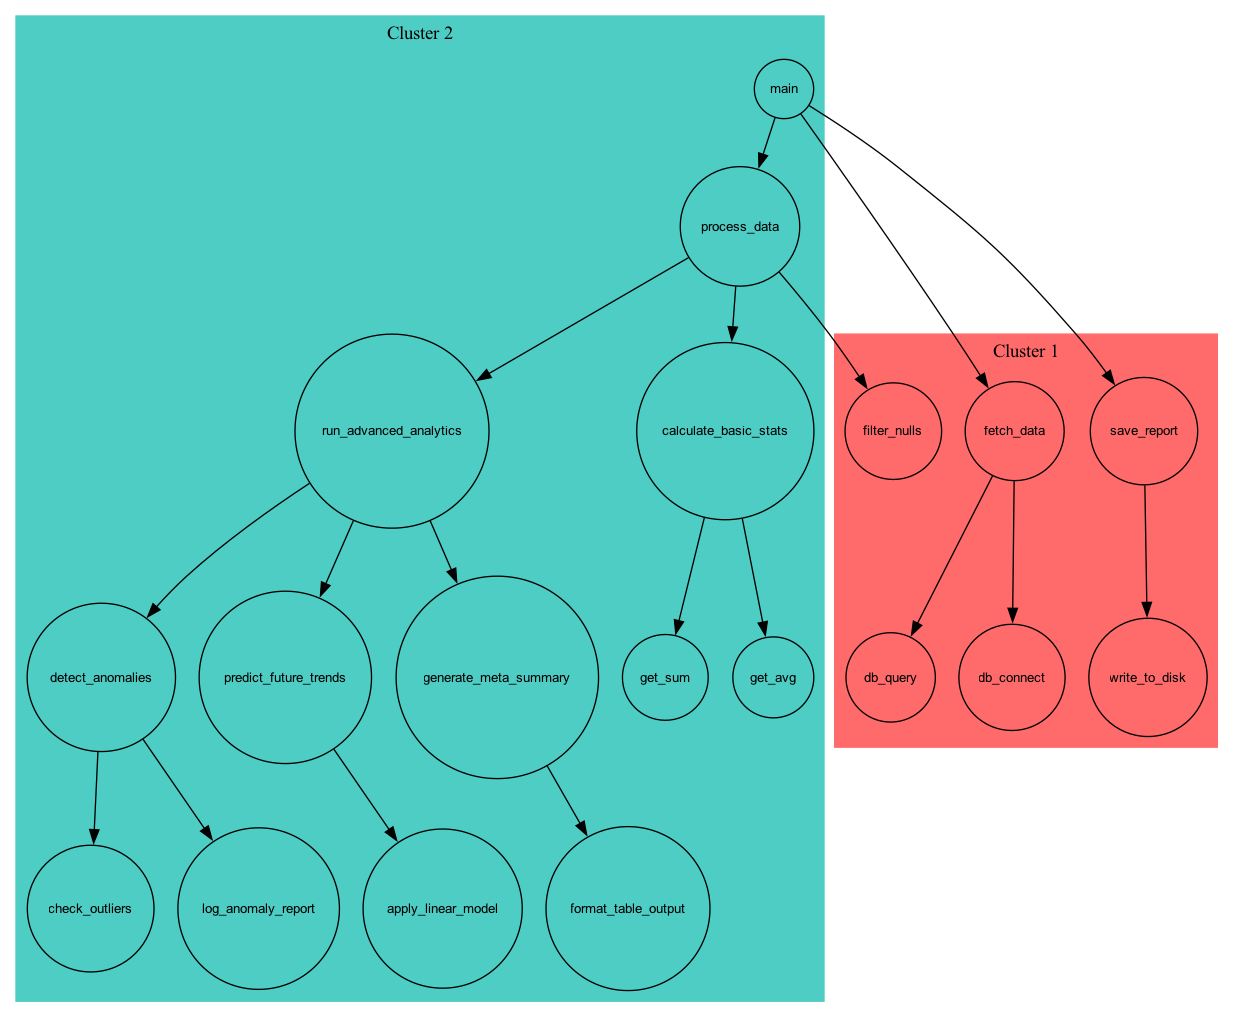


3   03 — A: EMBED_DIM=8          {2: ['calculate_basic_stats', 'fetch_data', 'main', 'process_data'], 1: ['db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'save_report', 'write_to_disk']} {2: ['calculate_basic_stats', 'db_connect', 'db_query', 'fetch_data', 'filter_nulls', 'get_avg', 'get_sum', 'main', 'save_report', 'write_to_disk'], 1: ['apply_linear_model', 'check_outliers', 'detect_anomalies', 'format_table_output', 'generate_meta_summary', 'log_anomaly_report', 'predict_future_trends', 'process_data', 'run_advanced_analytics']}     0.958911     1.160070

  ▶ Eksperimen 3: 03 — A: EMBED_DIM=8
    [t0] Clusters: {1: ['db_connect', 'db_query', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk'], 2: ['main', 'fetch_data', 'process_data', 'calculate_basic_stats']}


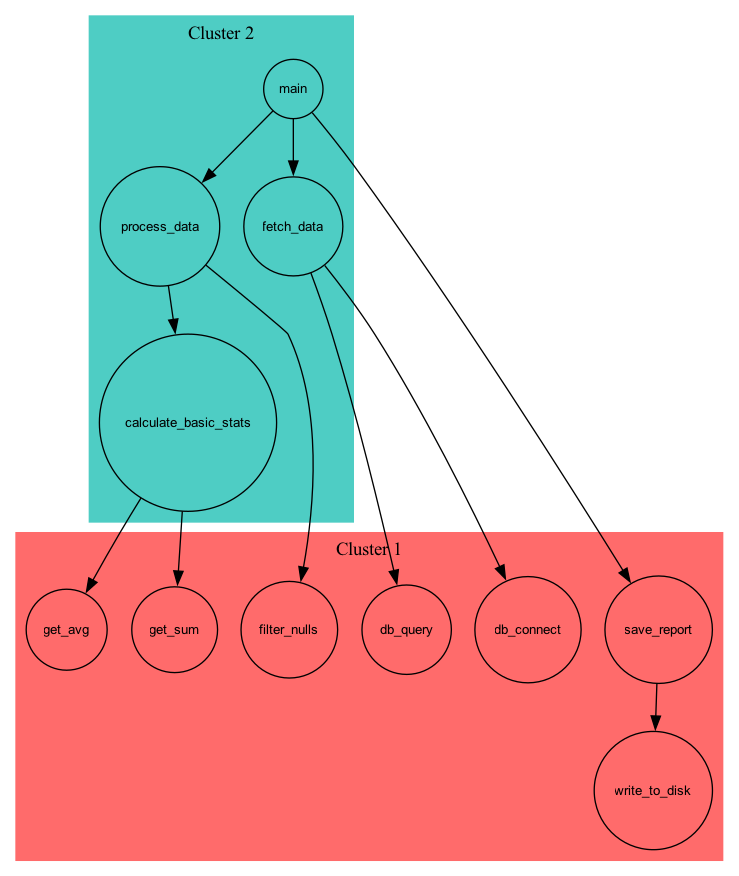

    [t1] Clusters: {1: ['process_data', 'run_advanced_analytics', 'detect_anomalies', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output'], 2: ['main', 'fetch_data', 'db_connect', 'db_query', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


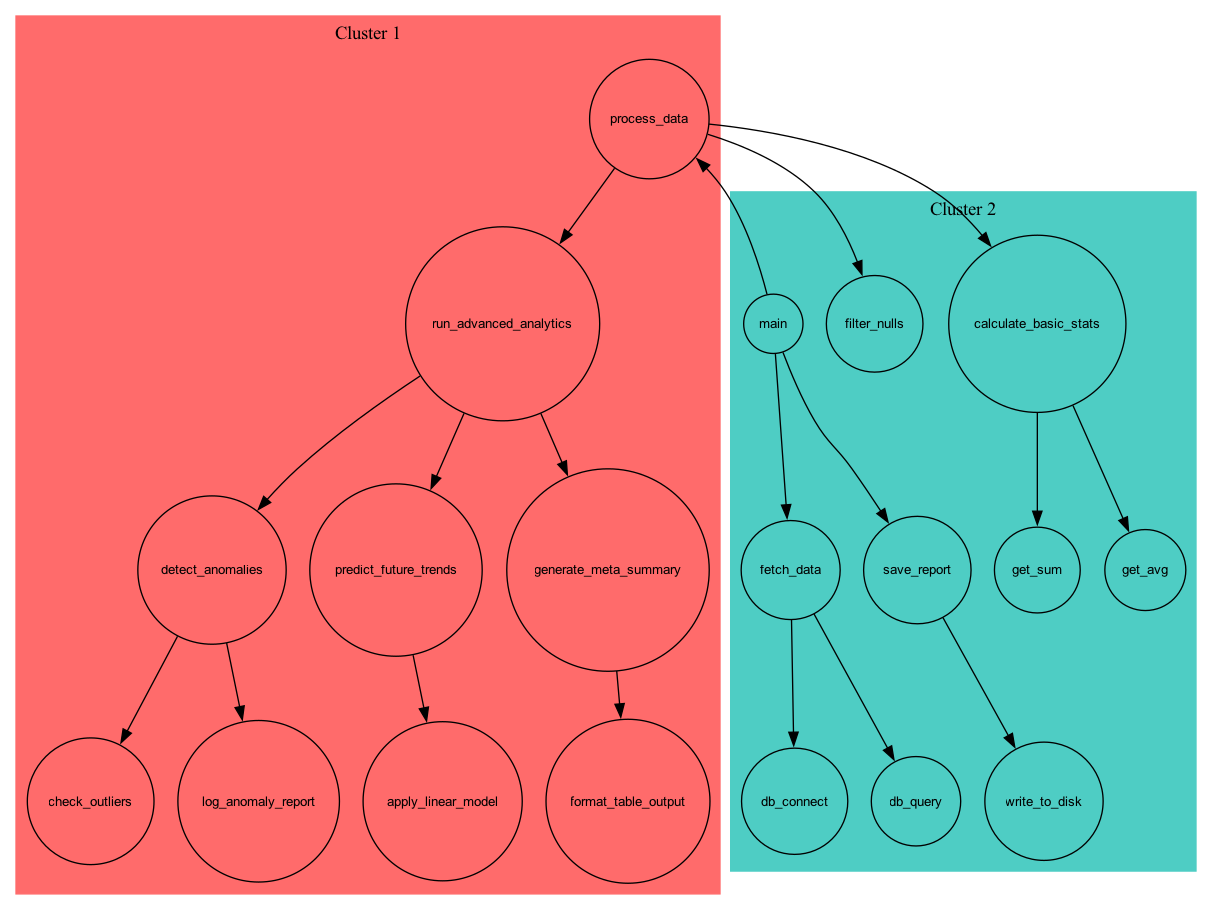


4   04 — A: EMBED_DIM=16         {2: ['db_connect', 'db_query', 'fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'generate_meta_summary', 'main', 'predict_future_trends', 'process_data', 'run_advanced_analytics', 'save_report'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'get_avg', 'get_sum', 'log_anomaly_report', 'write_to_disk']}     0.979498     1.183443

  ▶ Eksperimen 4: 04 — A: EMBED_DIM=16
    [t0] Clusters: {1: ['process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'db_connect', 'db_query', 'save_report', 'write_to_disk']}


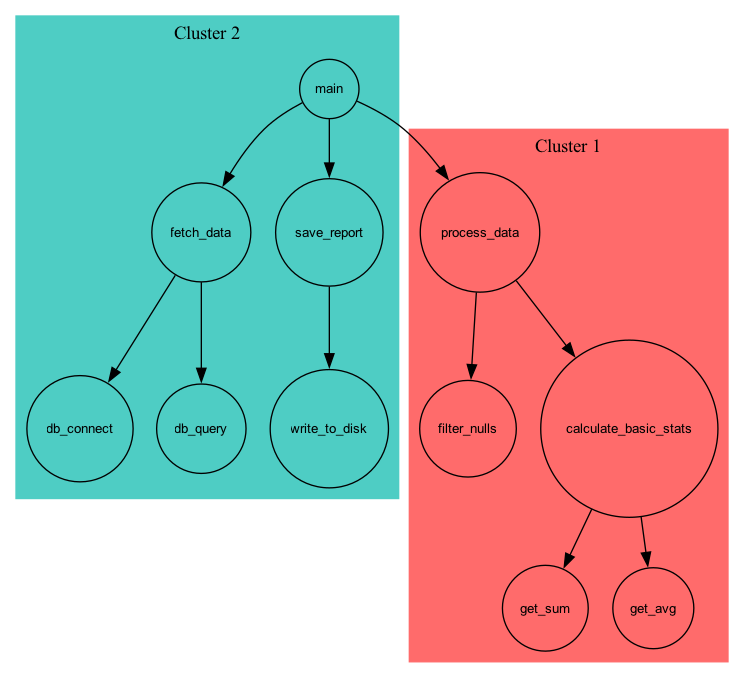

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'predict_future_trends', 'generate_meta_summary', 'calculate_basic_stats', 'save_report'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'apply_linear_model', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'write_to_disk']}


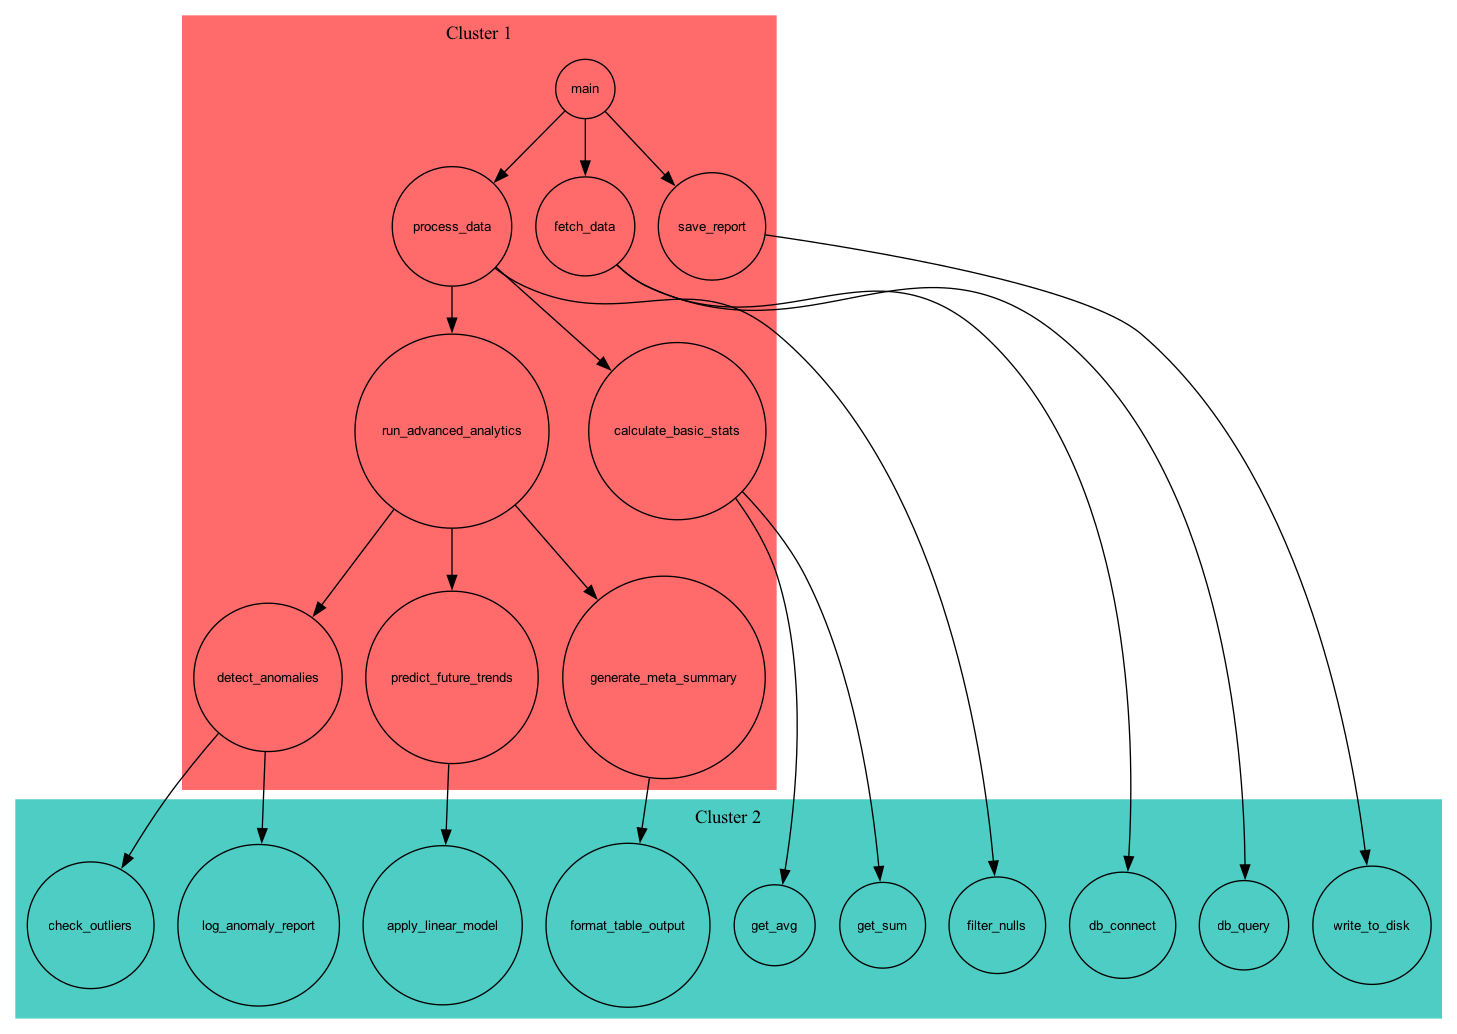


5   05 — B: WALK_LENGTH=5        {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 5: 05 — B: WALK_LENGTH=5
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


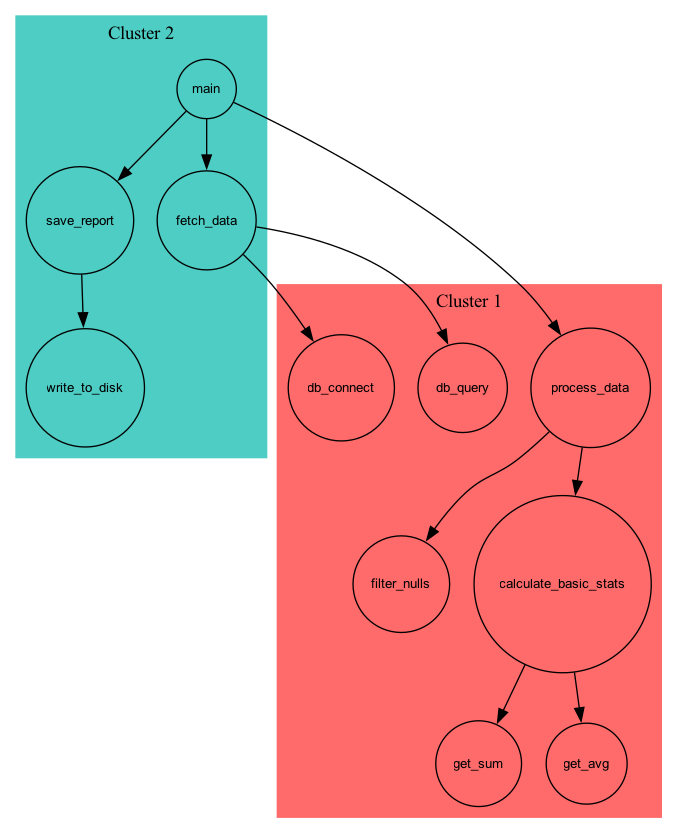

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


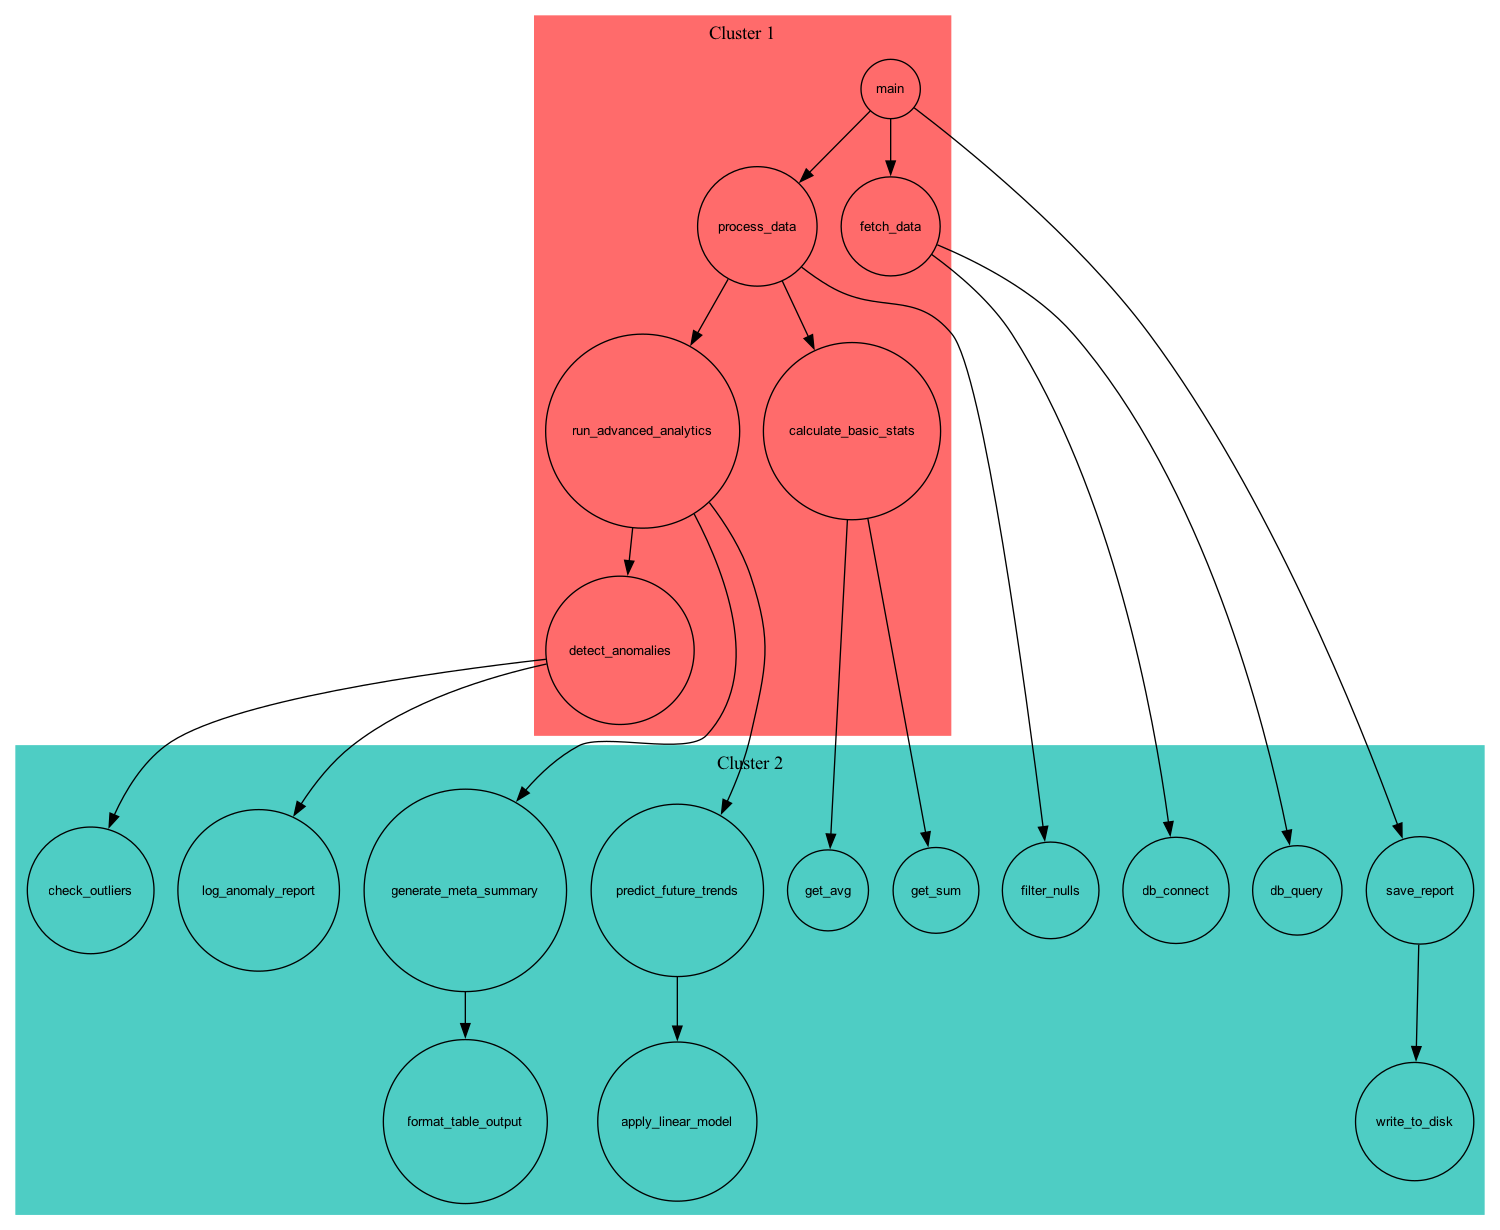


6   06 — B: WALK_LENGTH=20       {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 6: 06 — B: WALK_LENGTH=20
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


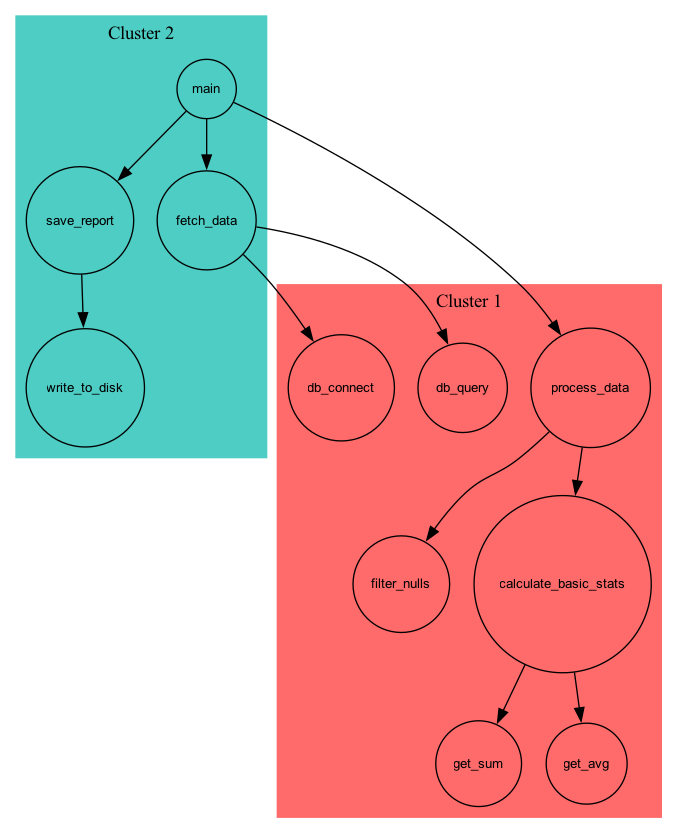

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


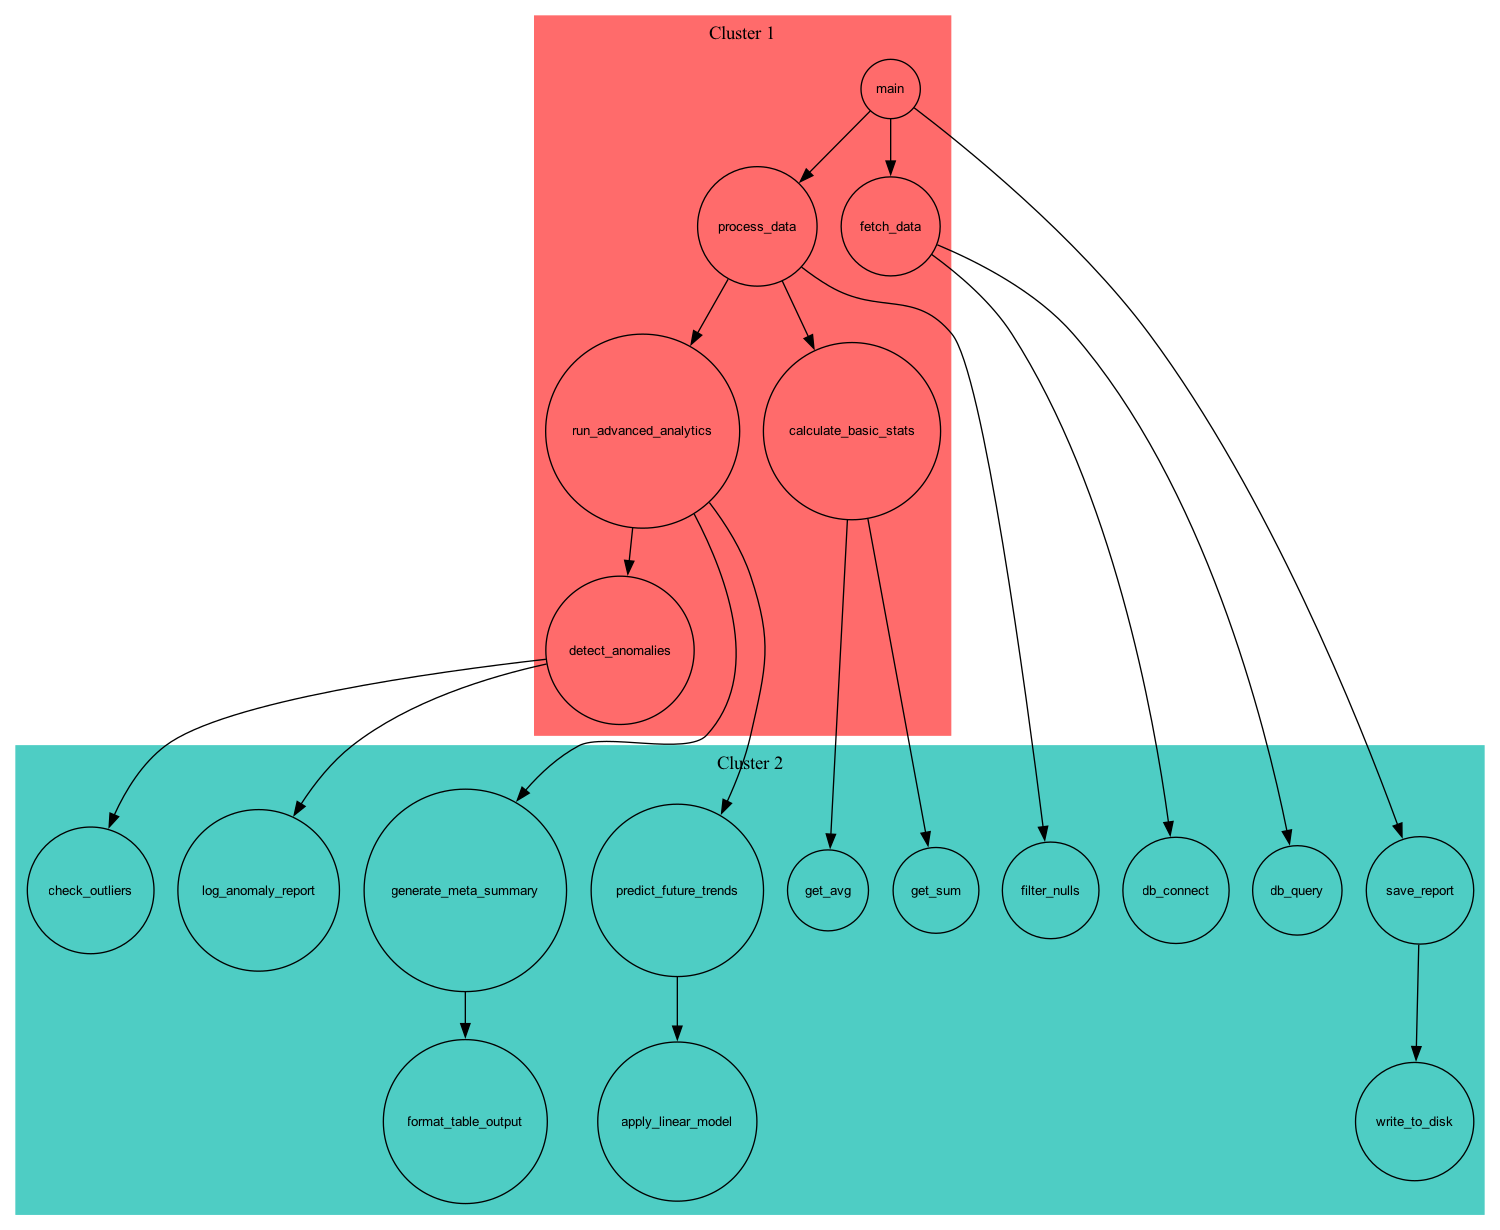


7   07 — B: WALK_LENGTH=40       {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 7: 07 — B: WALK_LENGTH=40
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


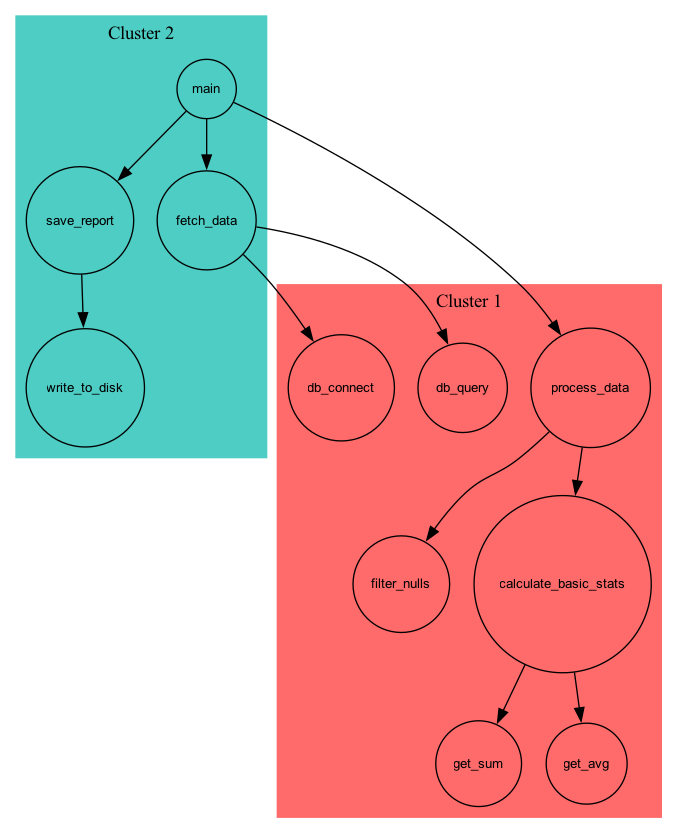

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


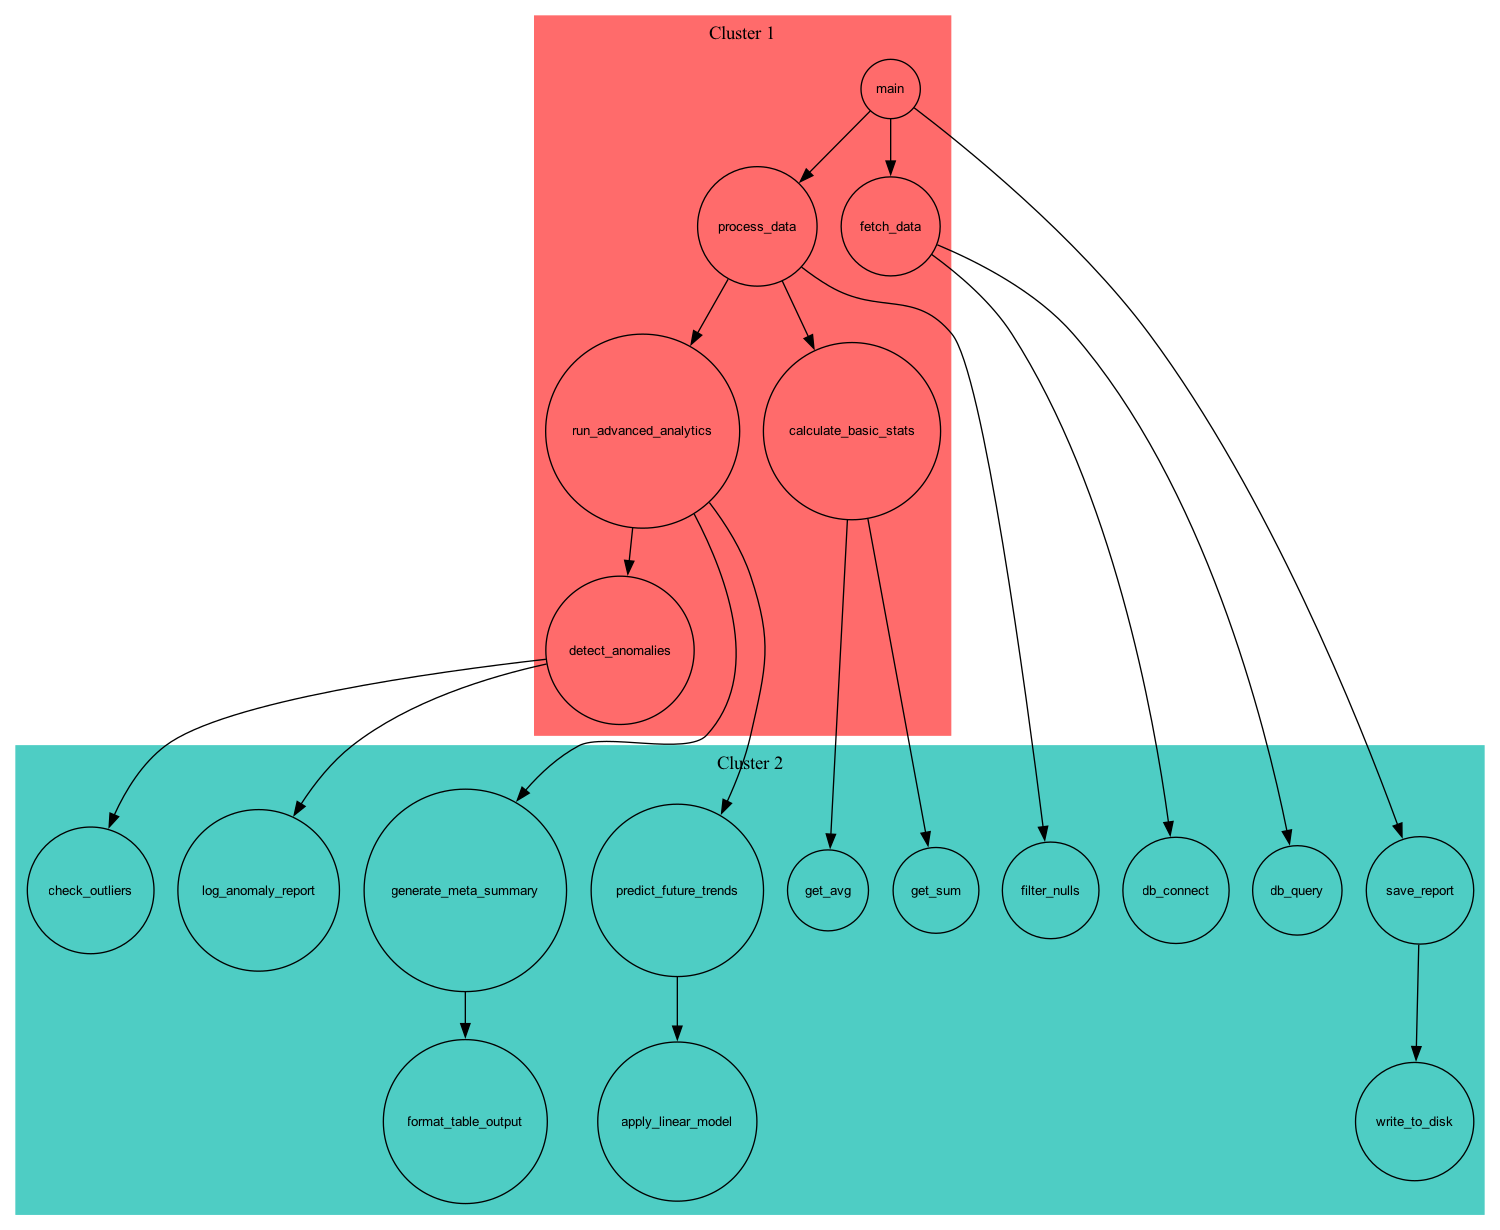


8   08 — C: NUM_WALKS=10         {2: ['calculate_basic_stats', 'db_query', 'main', 'save_report', 'write_to_disk'], 1: ['db_connect', 'fetch_data', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {2: ['calculate_basic_stats', 'db_query', 'detect_anomalies', 'fetch_data', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'main', 'predict_future_trends', 'process_data', 'run_advanced_analytics'], 1: ['apply_linear_model', 'check_outliers', 'db_connect', 'get_sum', 'log_anomaly_report', 'save_report', 'write_to_disk']}     1.377005     1.314739

  ▶ Eksperimen 8: 08 — C: NUM_WALKS=10
    [t0] Clusters: {1: ['fetch_data', 'db_connect', 'process_data', 'filter_nulls', 'get_sum', 'get_avg'], 2: ['main', 'db_query', 'calculate_basic_stats', 'save_report', 'write_to_disk']}


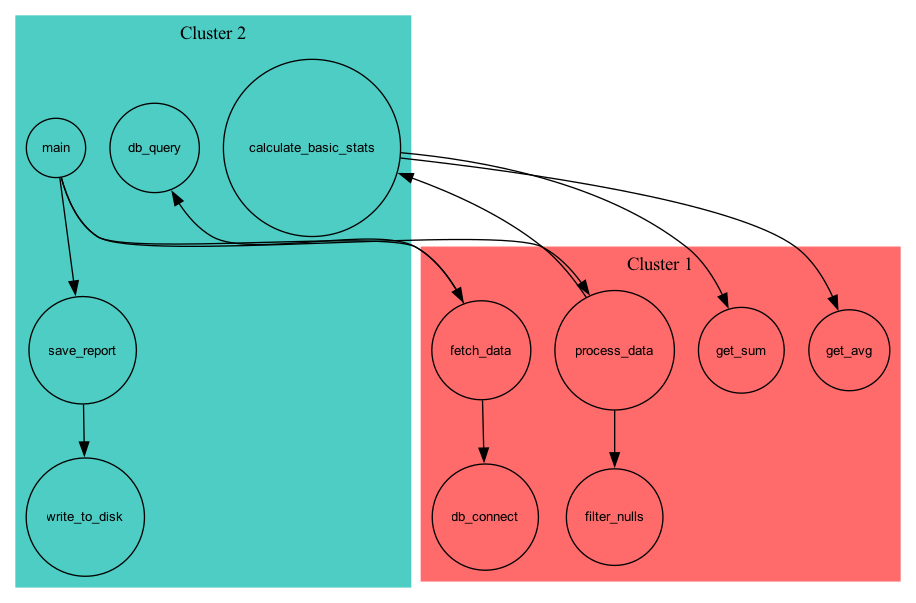

    [t1] Clusters: {1: ['db_connect', 'check_outliers', 'log_anomaly_report', 'apply_linear_model', 'get_sum', 'save_report', 'write_to_disk'], 2: ['main', 'fetch_data', 'db_query', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'predict_future_trends', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'calculate_basic_stats', 'get_avg']}


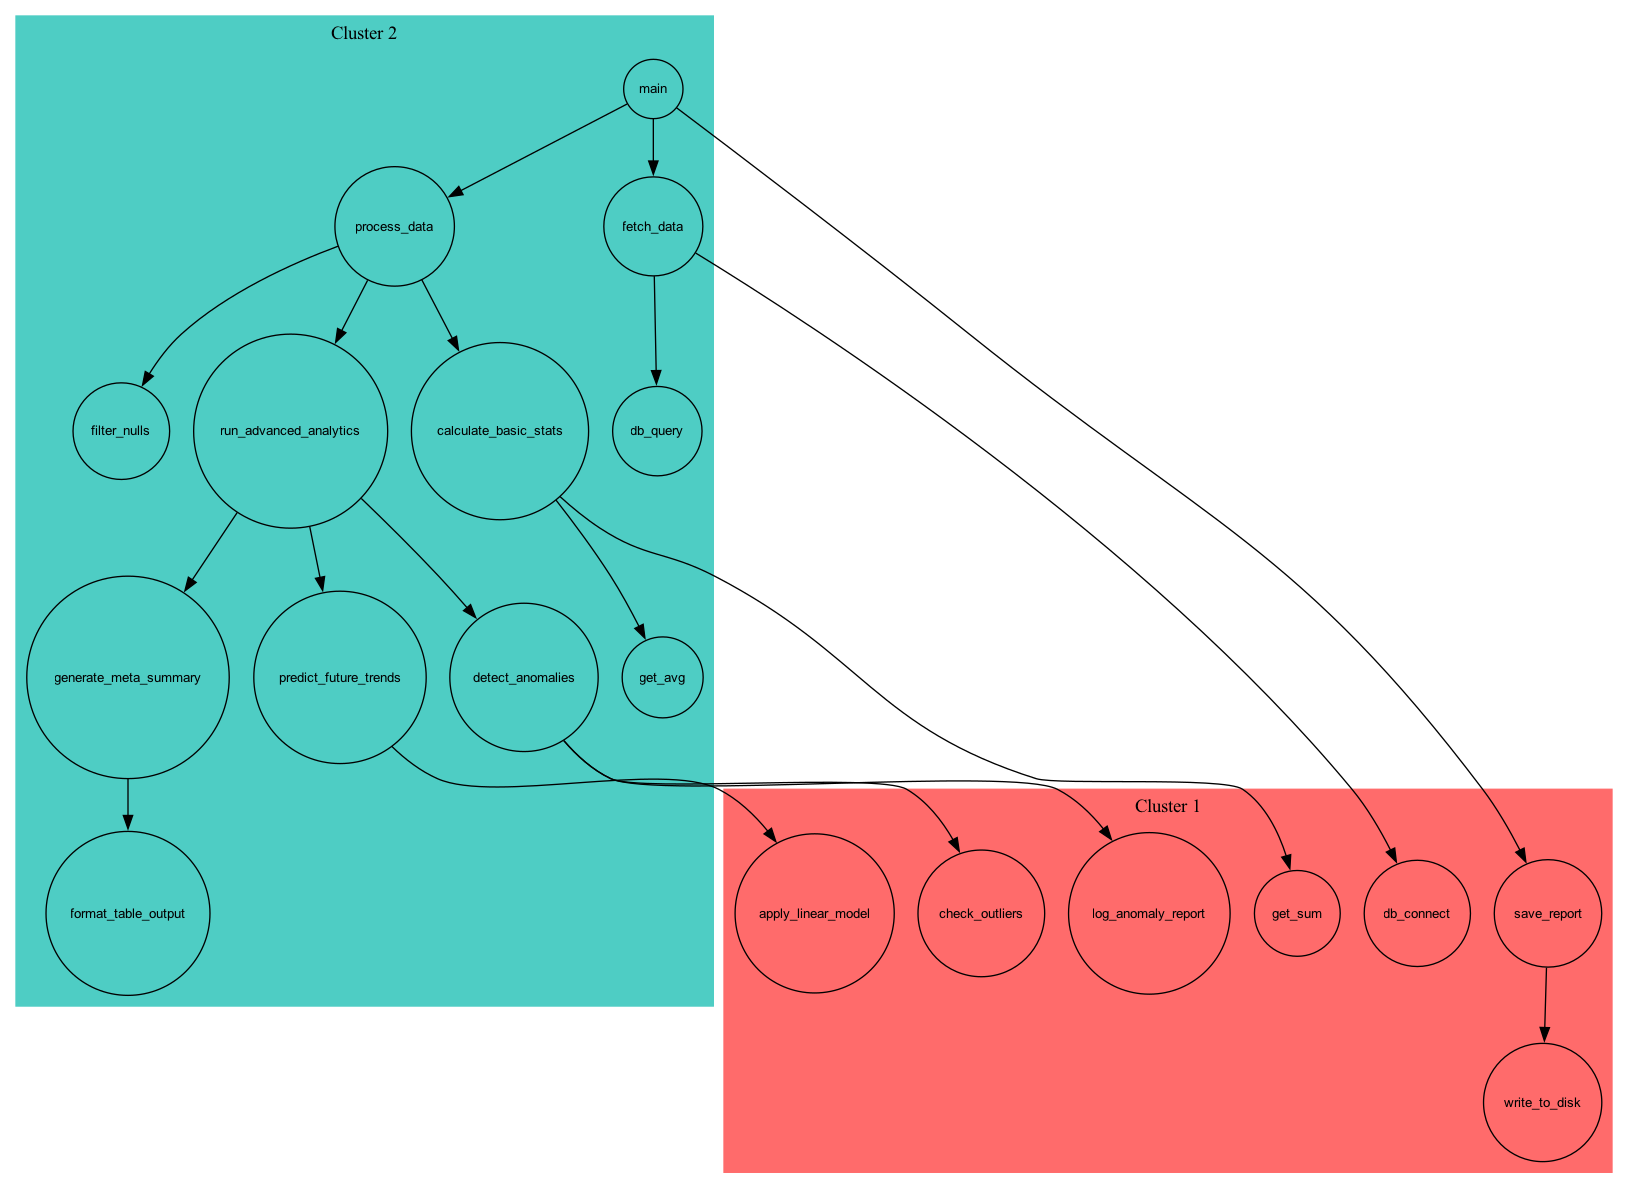


9   09 — C: NUM_WALKS=50         {2: ['db_connect', 'filter_nulls', 'main', 'process_data', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_query', 'fetch_data', 'get_avg', 'get_sum']} {2: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'predict_future_trends', 'process_data', 'run_advanced_analytics', 'save_report'], 1: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'write_to_disk']}     1.085544     0.662362

  ▶ Eksperimen 9: 09 — C: NUM_WALKS=50
    [t0] Clusters: {1: ['fetch_data', 'db_query', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'db_connect', 'process_data', 'filter_nulls', 'save_report', 'write_to_disk']}


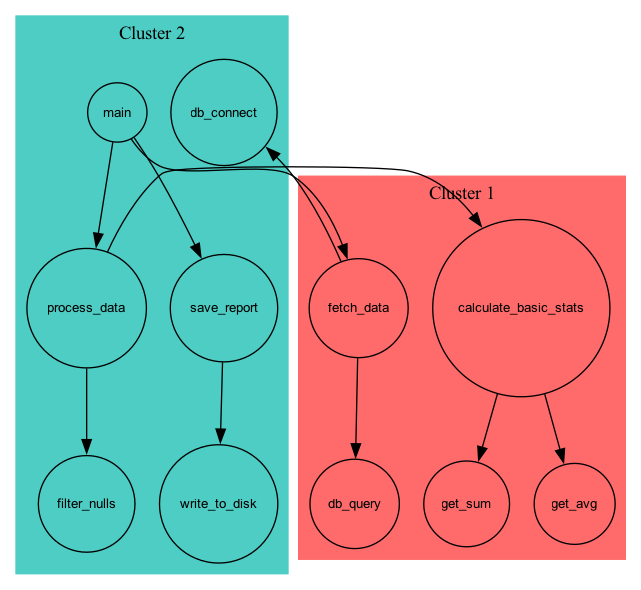

    [t1] Clusters: {1: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'write_to_disk'], 2: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'predict_future_trends', 'calculate_basic_stats', 'save_report']}


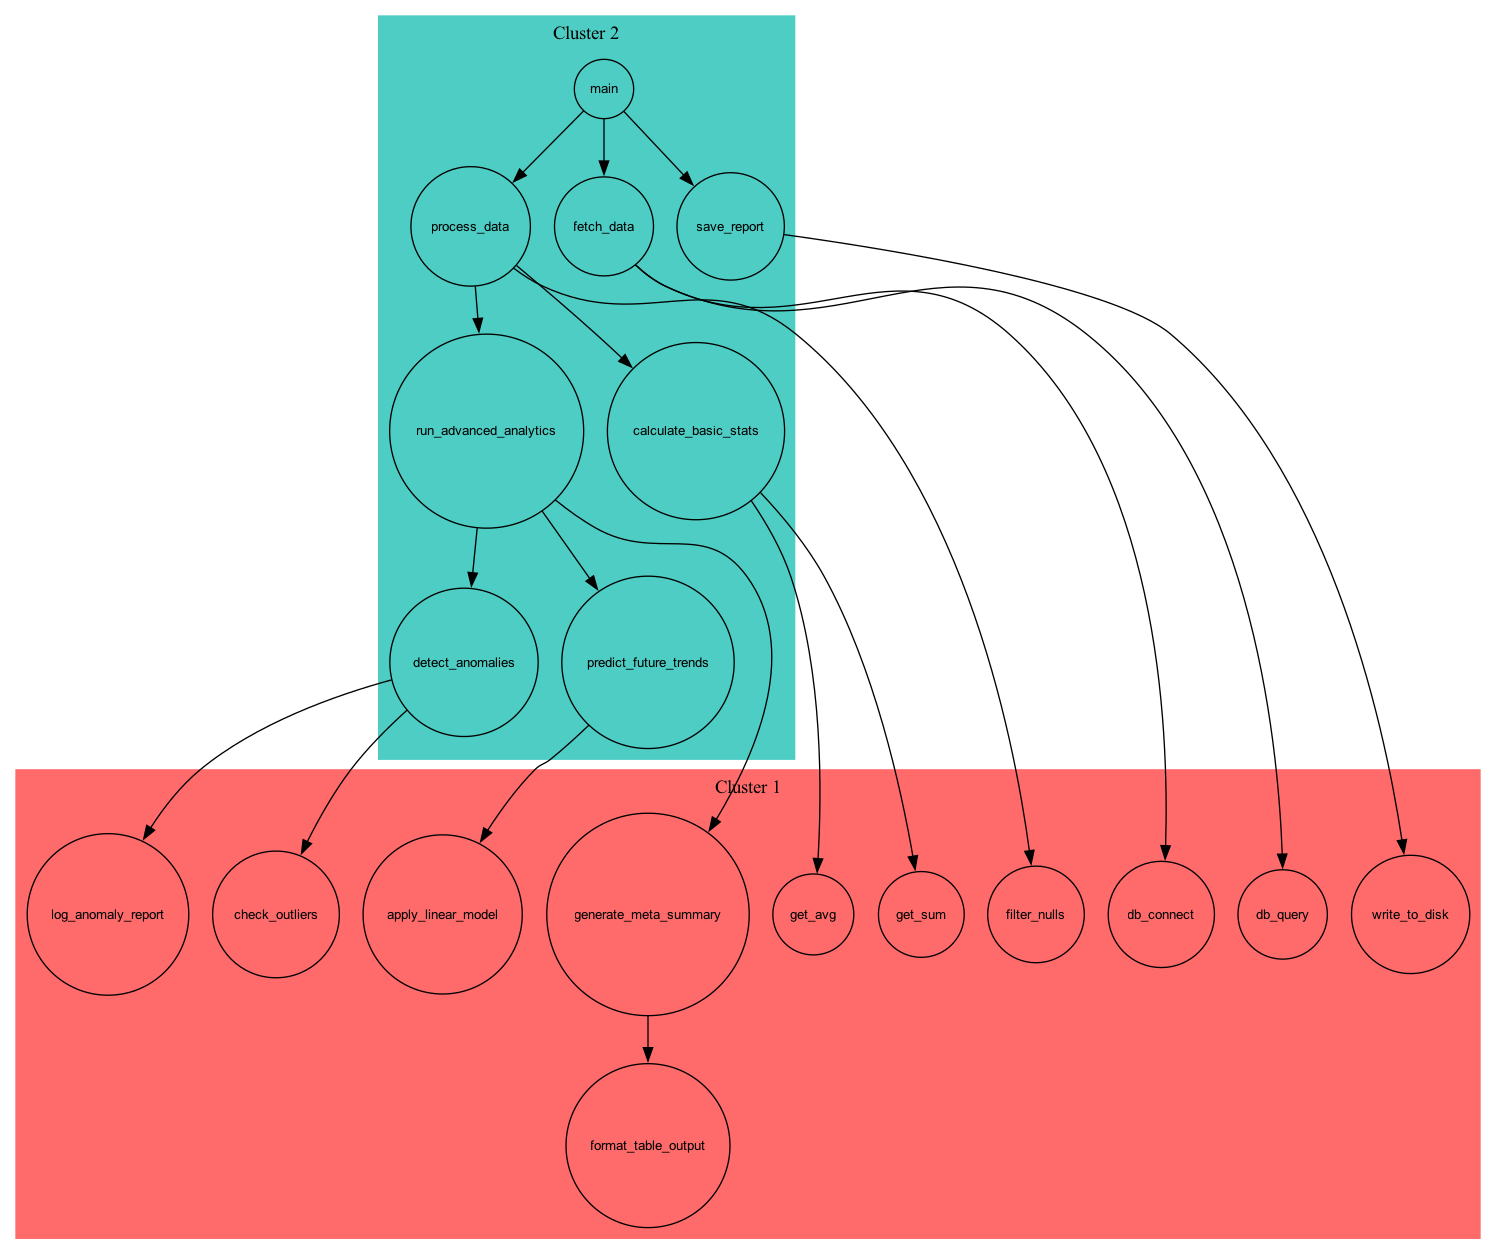


10  10 — C: NUM_WALKS=100        {2: ['calculate_basic_stats', 'fetch_data', 'main', 'process_data', 'save_report'], 1: ['db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'write_to_disk']} {1: ['db_connect', 'db_query', 'fetch_data', 'filter_nulls', 'main', 'predict_future_trends', 'save_report'], 2: ['apply_linear_model', 'calculate_basic_stats', 'check_outliers', 'detect_anomalies', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'process_data', 'run_advanced_analytics', 'write_to_disk']}     0.656859     1.008148

  ▶ Eksperimen 10: 10 — C: NUM_WALKS=100
    [t0] Clusters: {1: ['db_connect', 'db_query', 'filter_nulls', 'get_sum', 'get_avg', 'write_to_disk'], 2: ['main', 'fetch_data', 'process_data', 'calculate_basic_stats', 'save_report']}


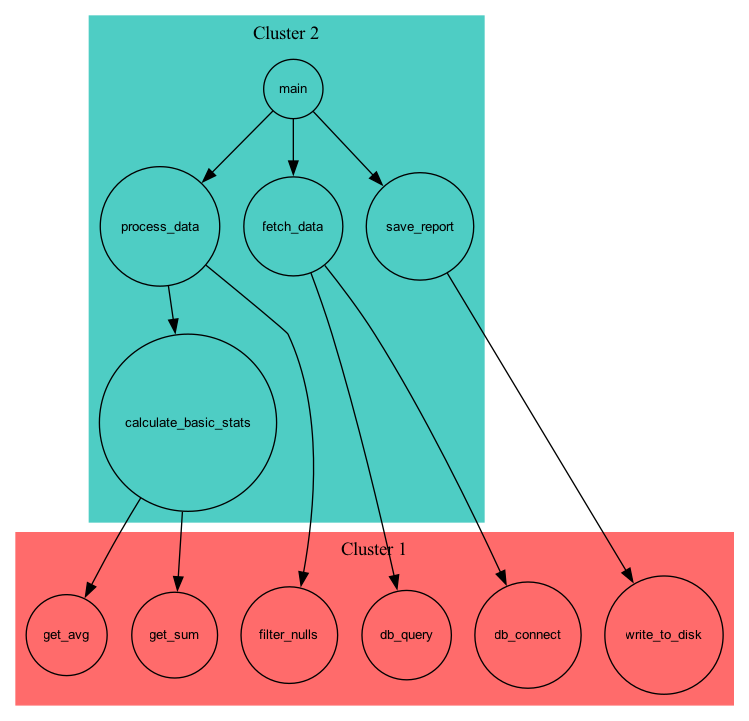

    [t1] Clusters: {1: ['main', 'fetch_data', 'db_connect', 'db_query', 'predict_future_trends', 'filter_nulls', 'save_report'], 2: ['process_data', 'run_advanced_analytics', 'detect_anomalies', 'check_outliers', 'log_anomaly_report', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'calculate_basic_stats', 'get_sum', 'get_avg', 'write_to_disk']}


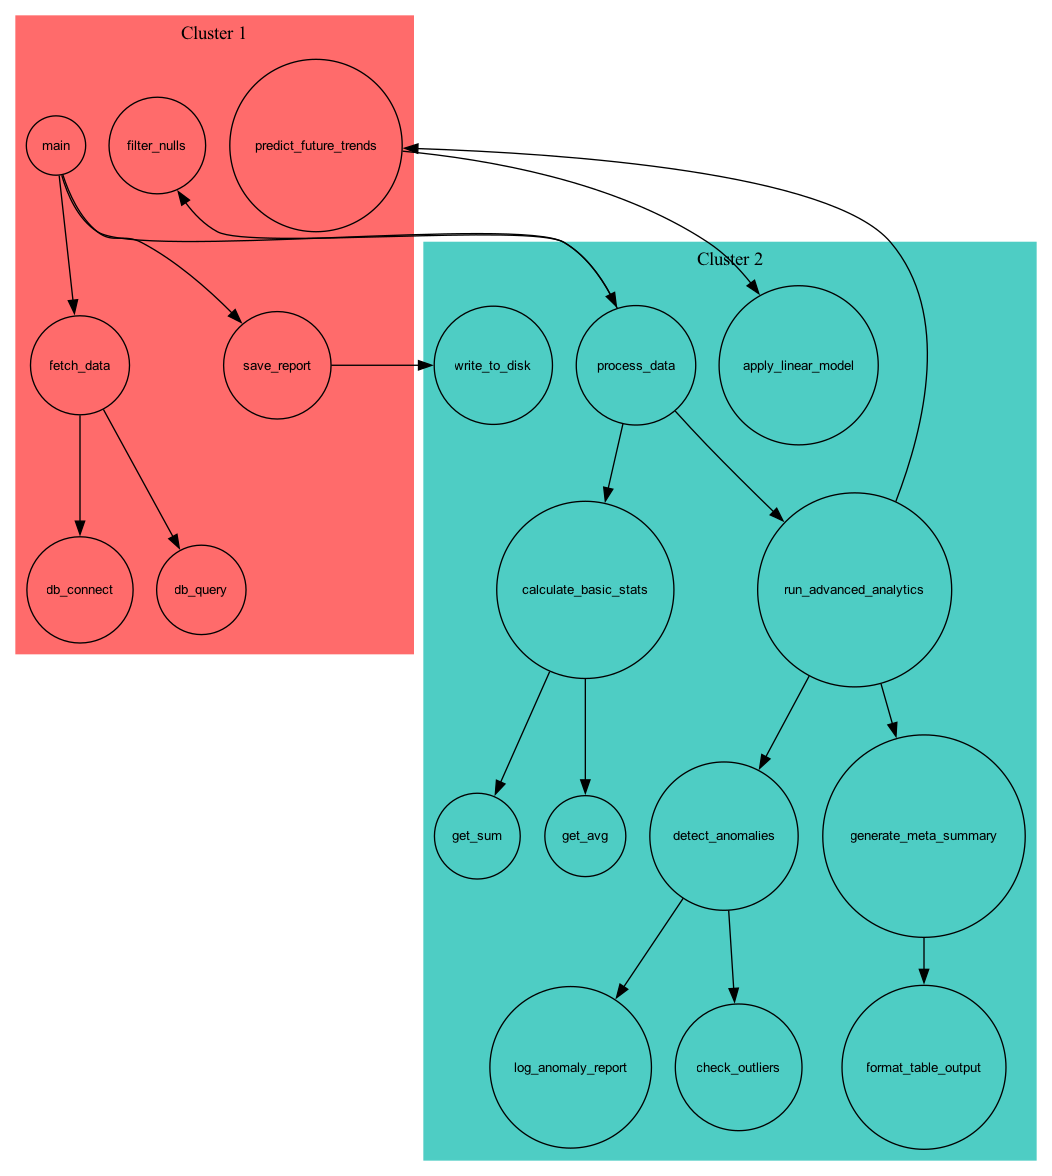


11  11 — C: NUM_WALKS=500        {1: ['fetch_data', 'main', 'process_data'], 2: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'save_report', 'write_to_disk']} {2: ['calculate_basic_stats', 'db_connect', 'db_query', 'fetch_data', 'filter_nulls', 'generate_meta_summary', 'get_avg', 'get_sum', 'main', 'process_data', 'save_report', 'write_to_disk'], 1: ['apply_linear_model', 'check_outliers', 'detect_anomalies', 'format_table_output', 'log_anomaly_report', 'predict_future_trends', 'run_advanced_analytics']}     1.086333     1.115963

  ▶ Eksperimen 11: 11 — C: NUM_WALKS=500
    [t0] Clusters: {1: ['main', 'fetch_data', 'process_data'], 2: ['db_connect', 'db_query', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


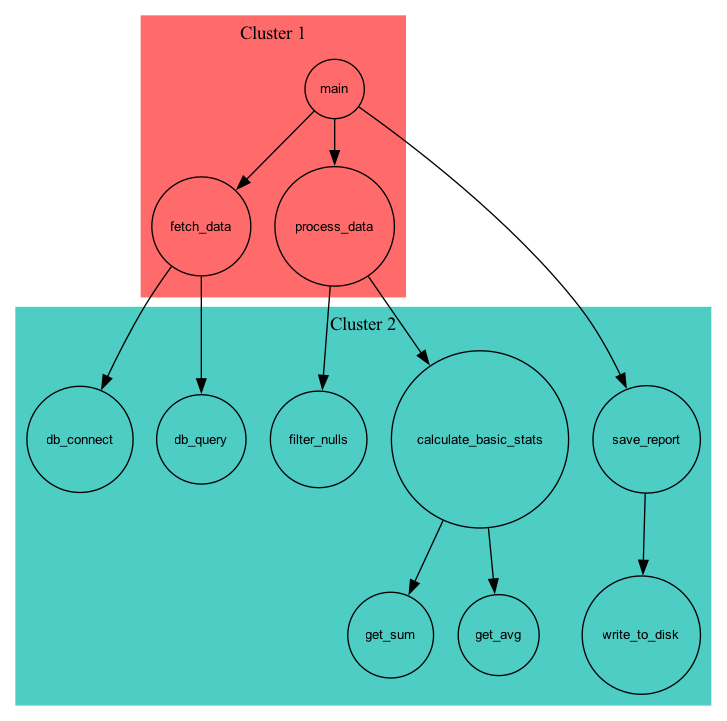

    [t1] Clusters: {1: ['run_advanced_analytics', 'detect_anomalies', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'format_table_output'], 2: ['main', 'fetch_data', 'db_connect', 'db_query', 'process_data', 'generate_meta_summary', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


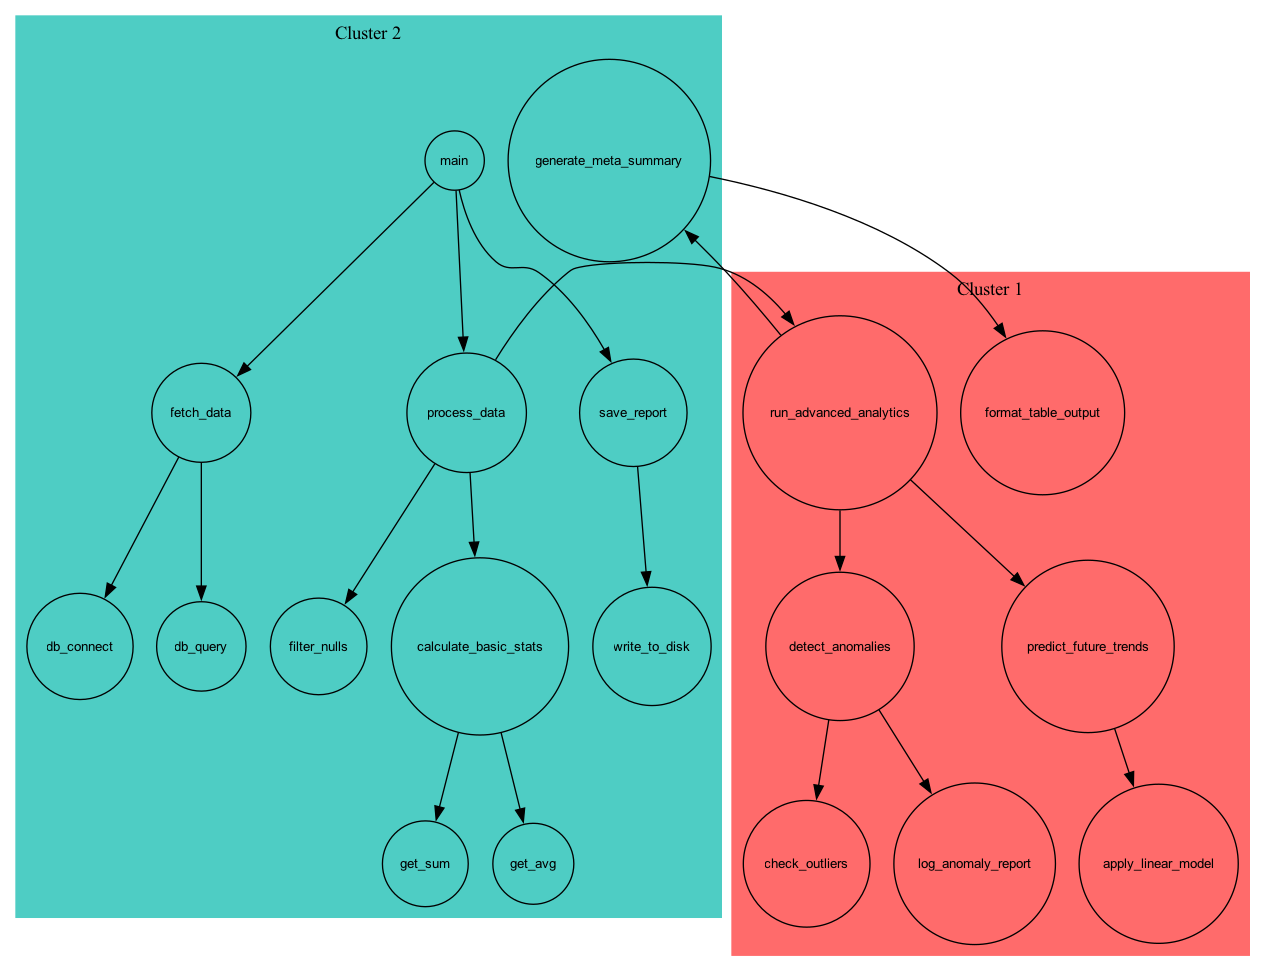


12  12 — D: P_RETURN=0.25        {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 12: 12 — D: P_RETURN=0.25
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


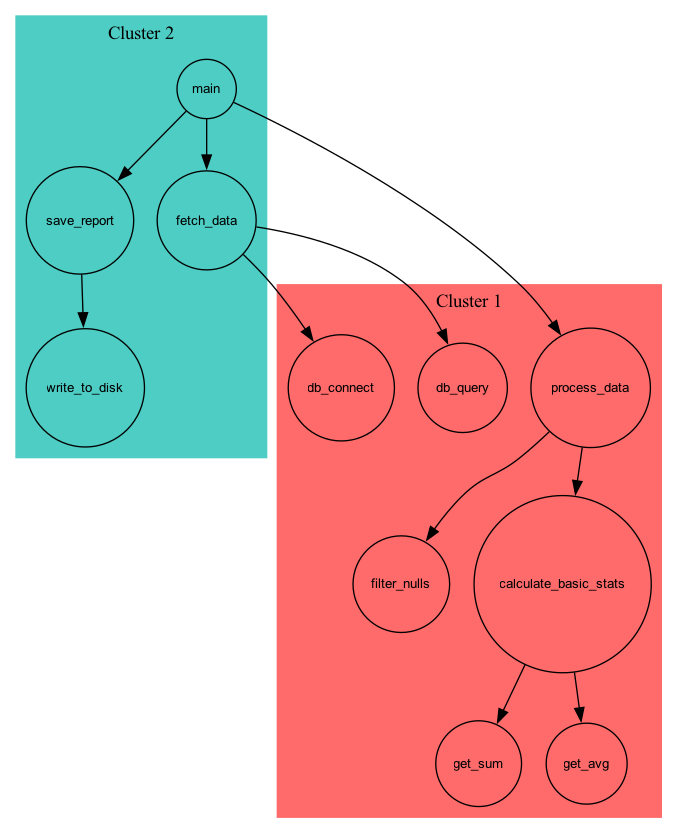

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


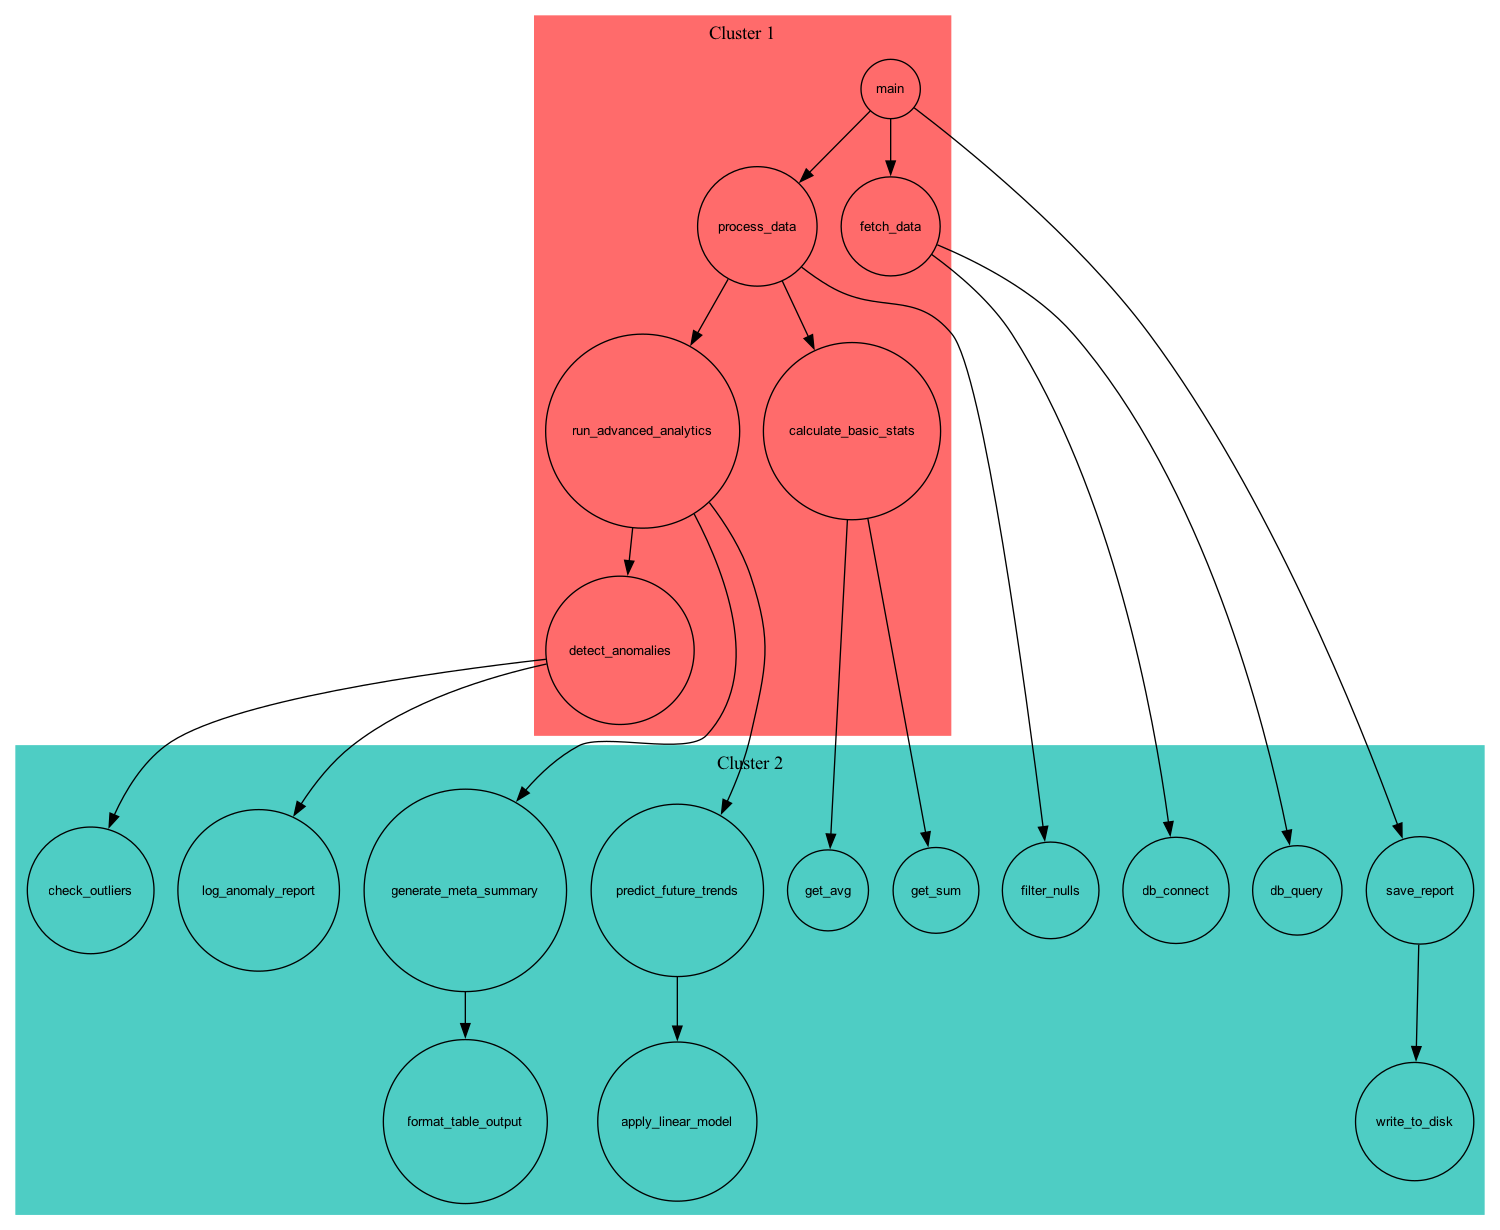


13  13 — D: P_RETURN=0.5         {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 13: 13 — D: P_RETURN=0.5
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


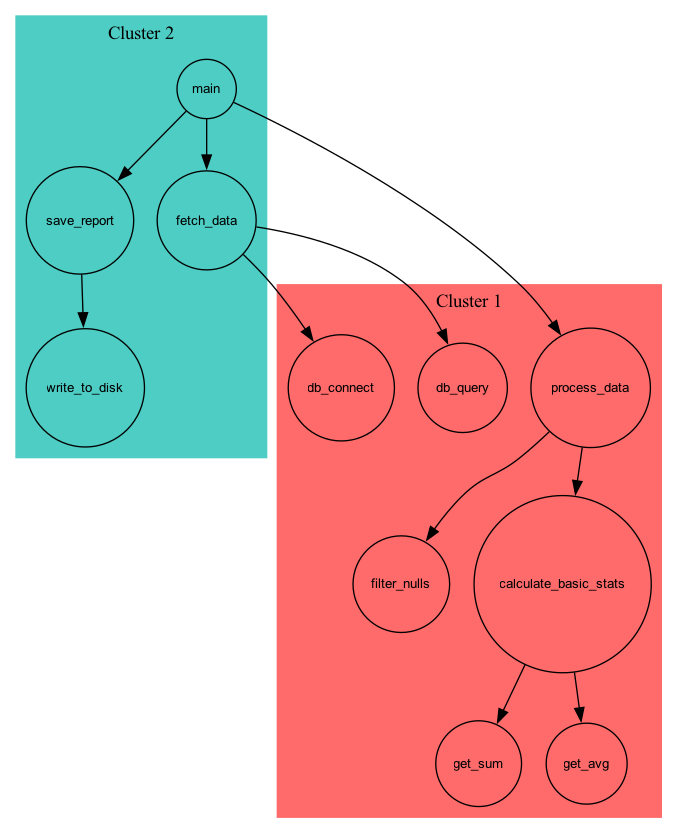

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


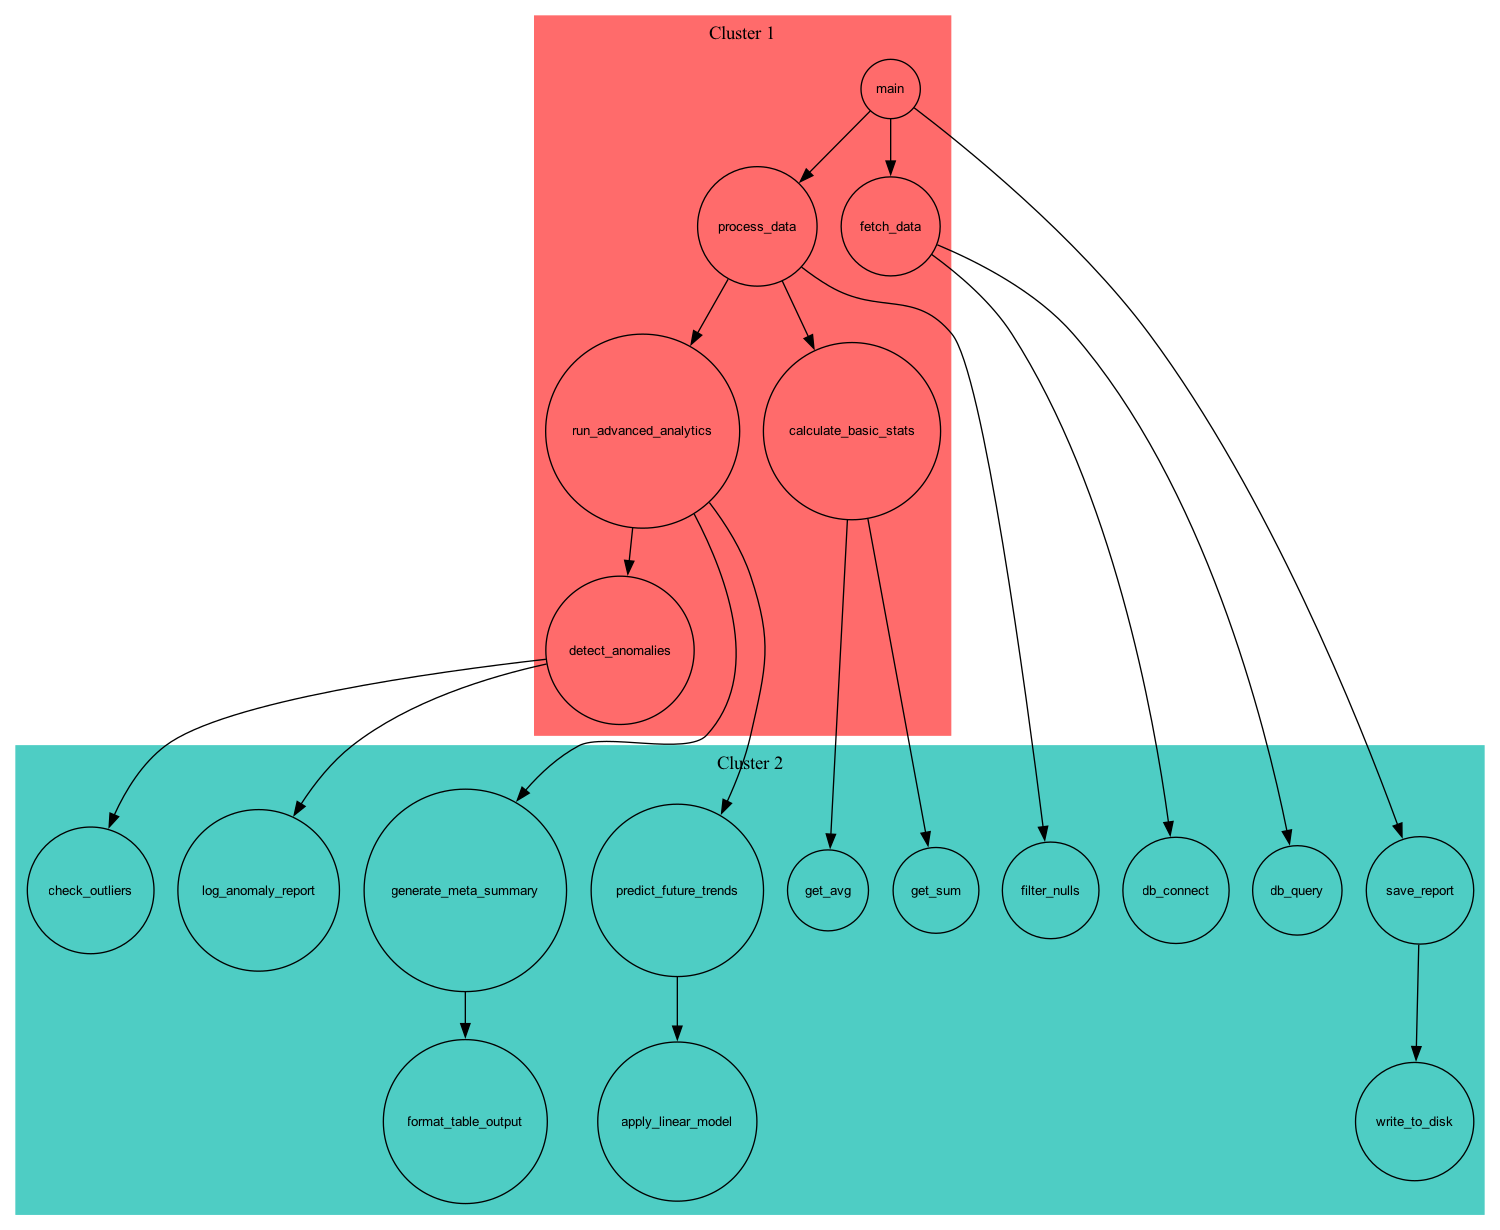


14  14 — D: P_RETURN=2.0         {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 14: 14 — D: P_RETURN=2.0
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


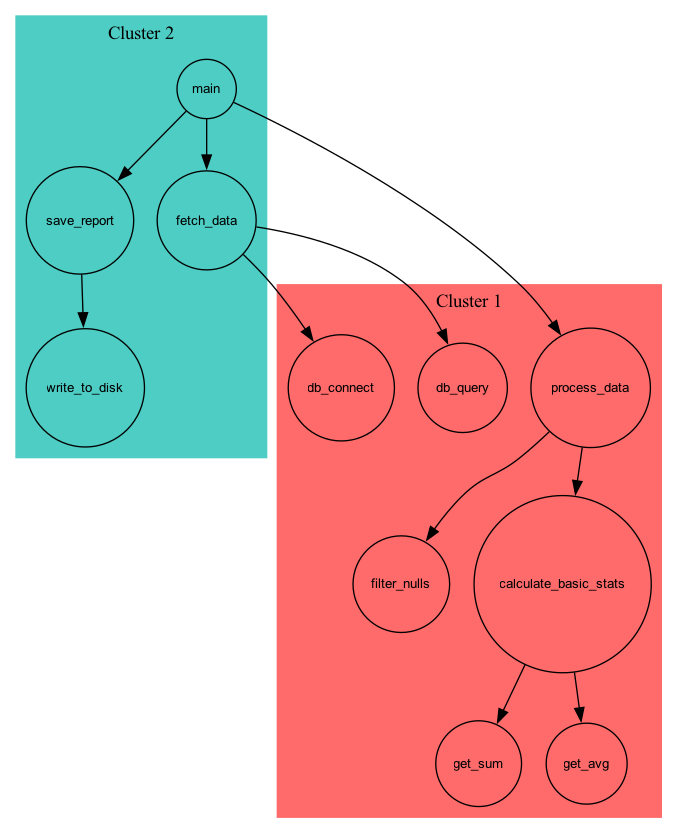

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


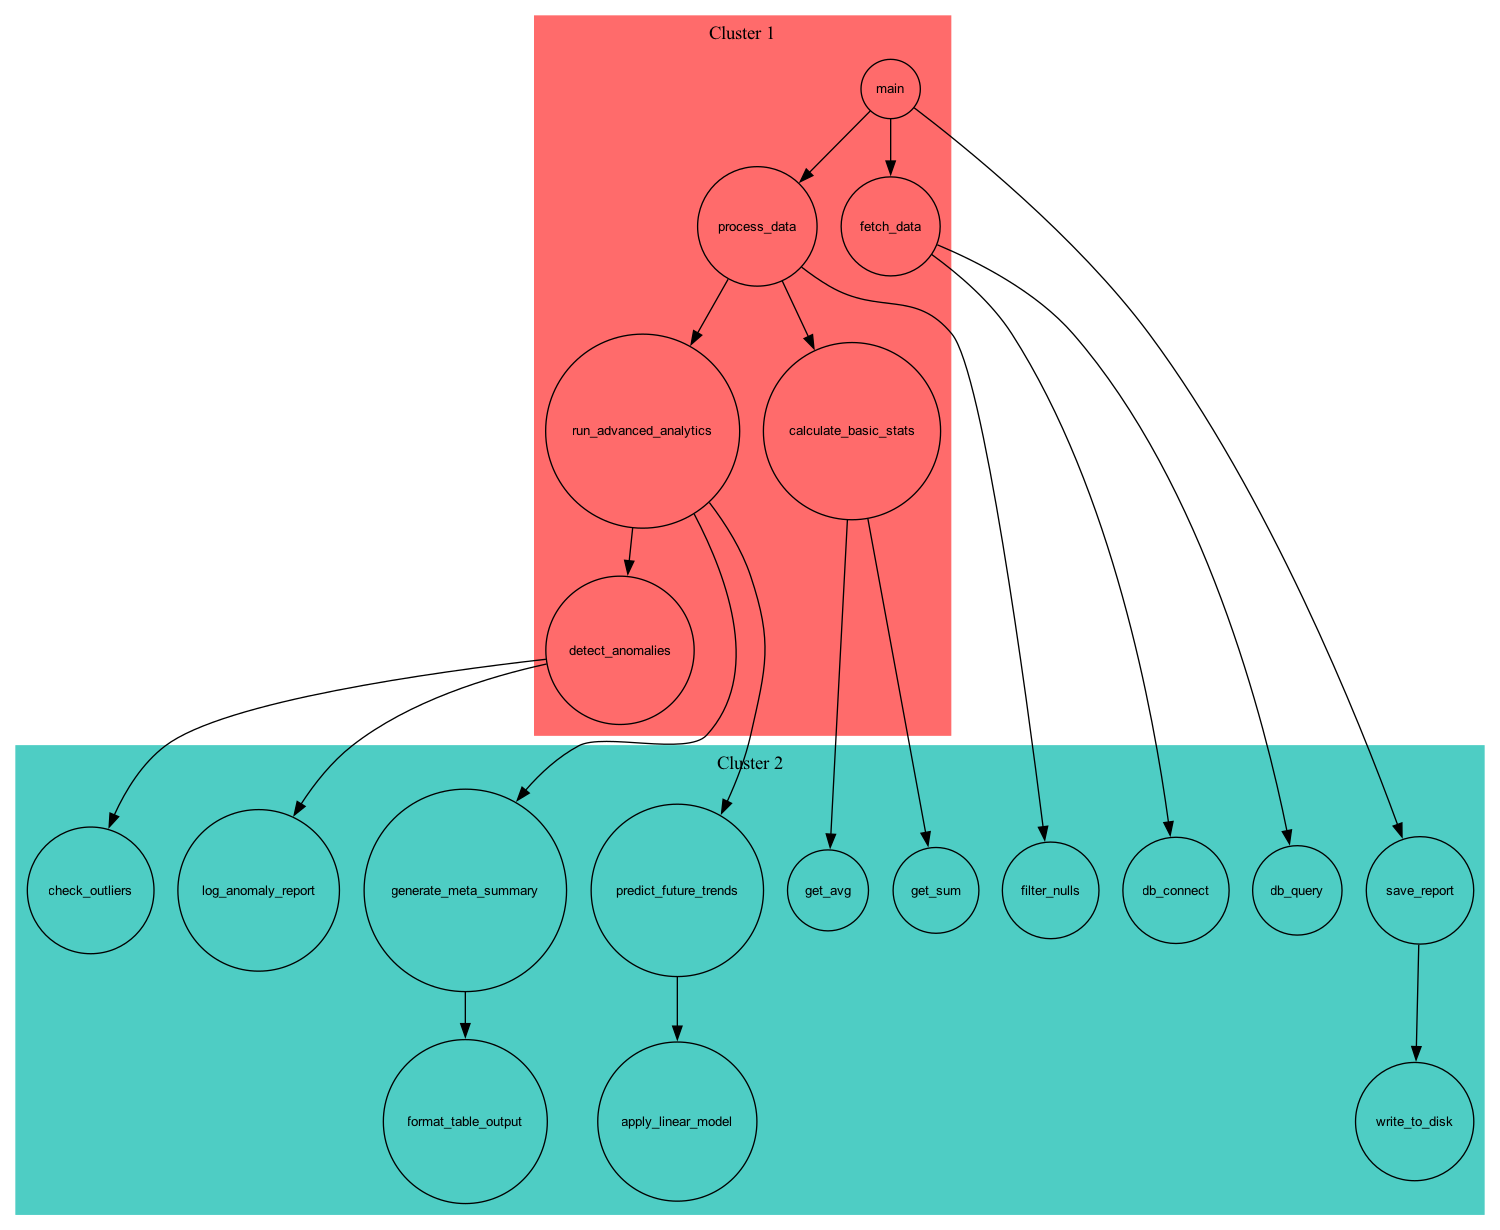


15  15 — D: P_RETURN=4.0         {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 15: 15 — D: P_RETURN=4.0
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


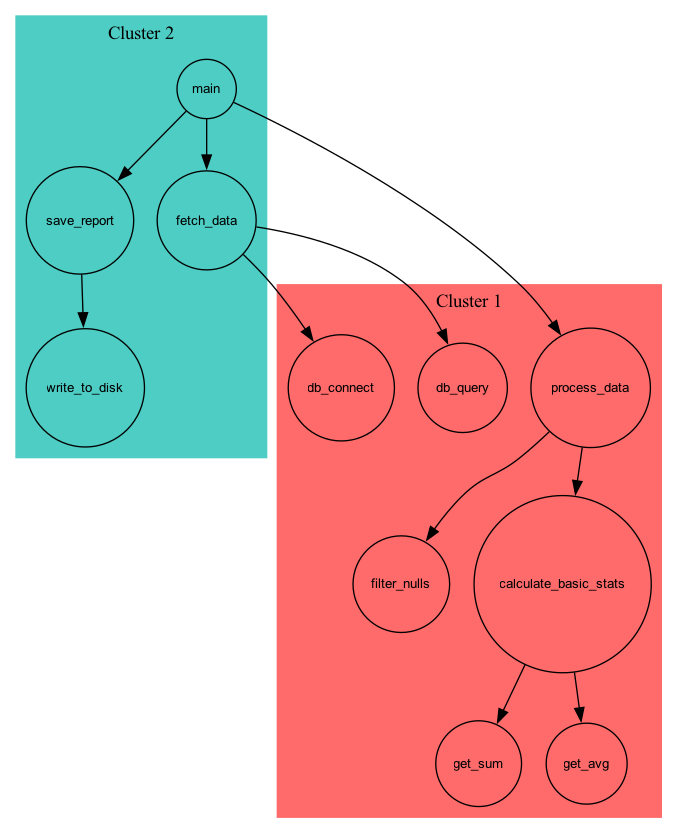

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


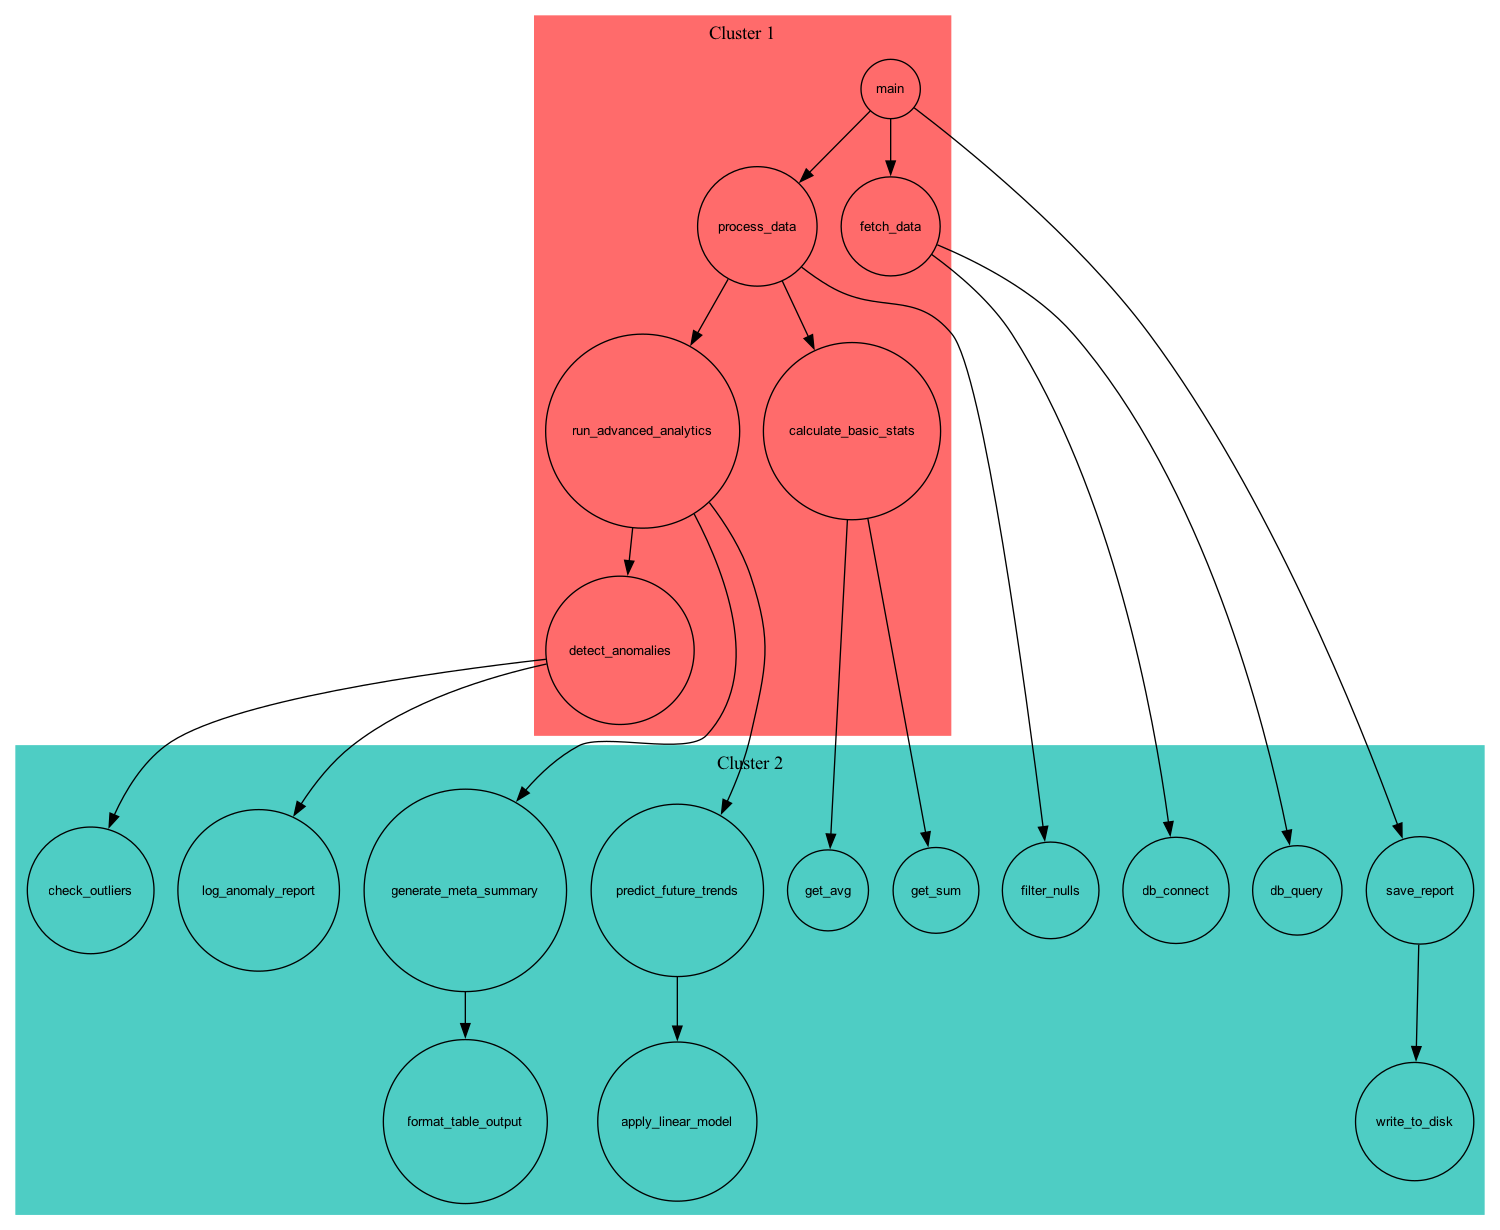


16  16 — E: Q_INOUT=0.25         {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 16: 16 — E: Q_INOUT=0.25
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


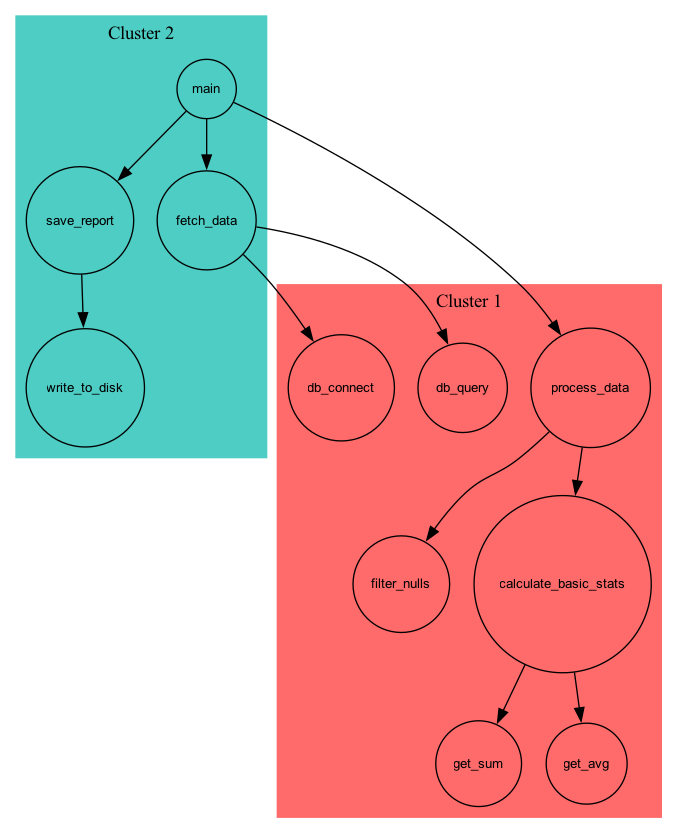

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


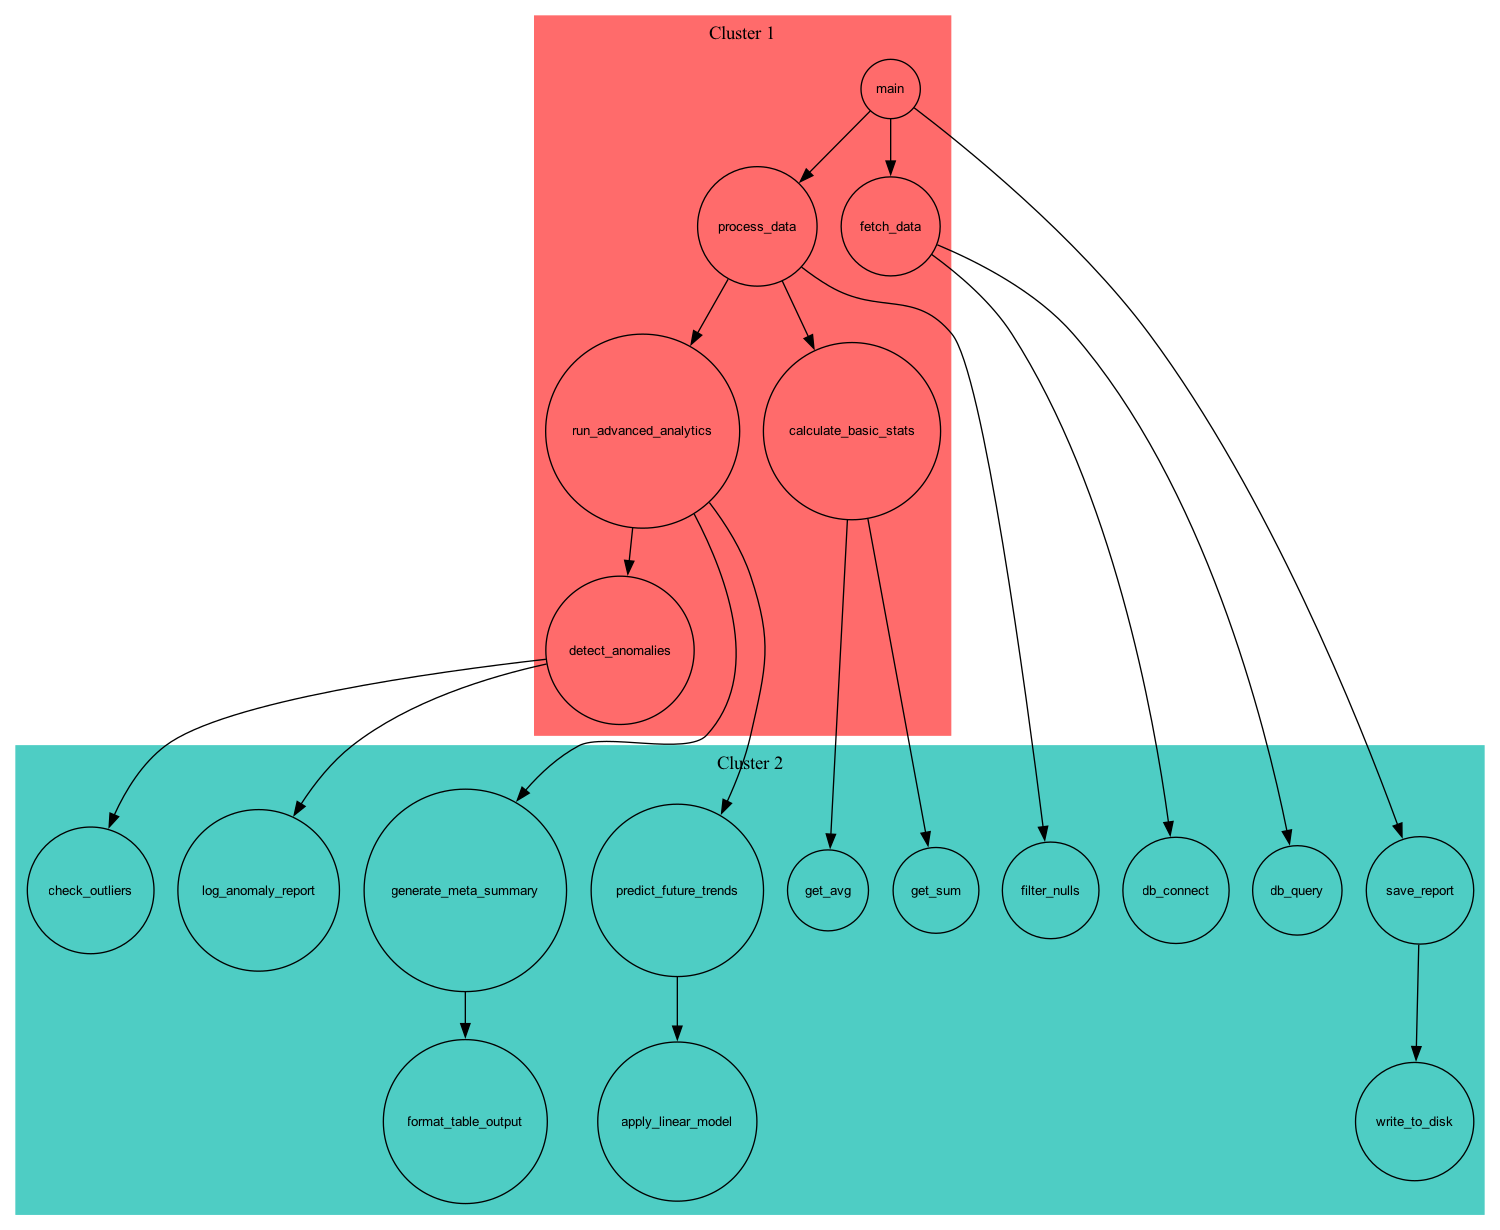


17  17 — E: Q_INOUT=0.5          {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 17: 17 — E: Q_INOUT=0.5
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


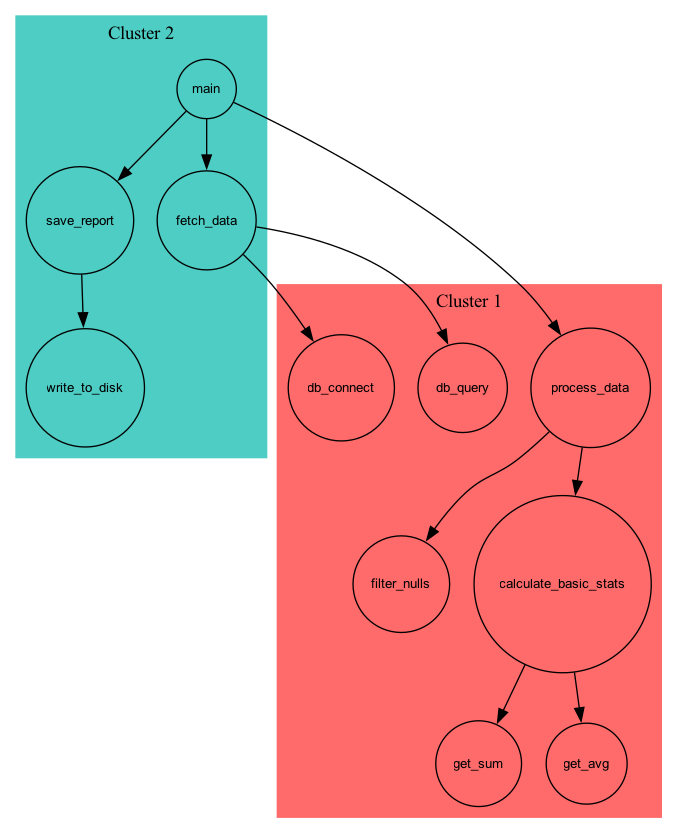

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


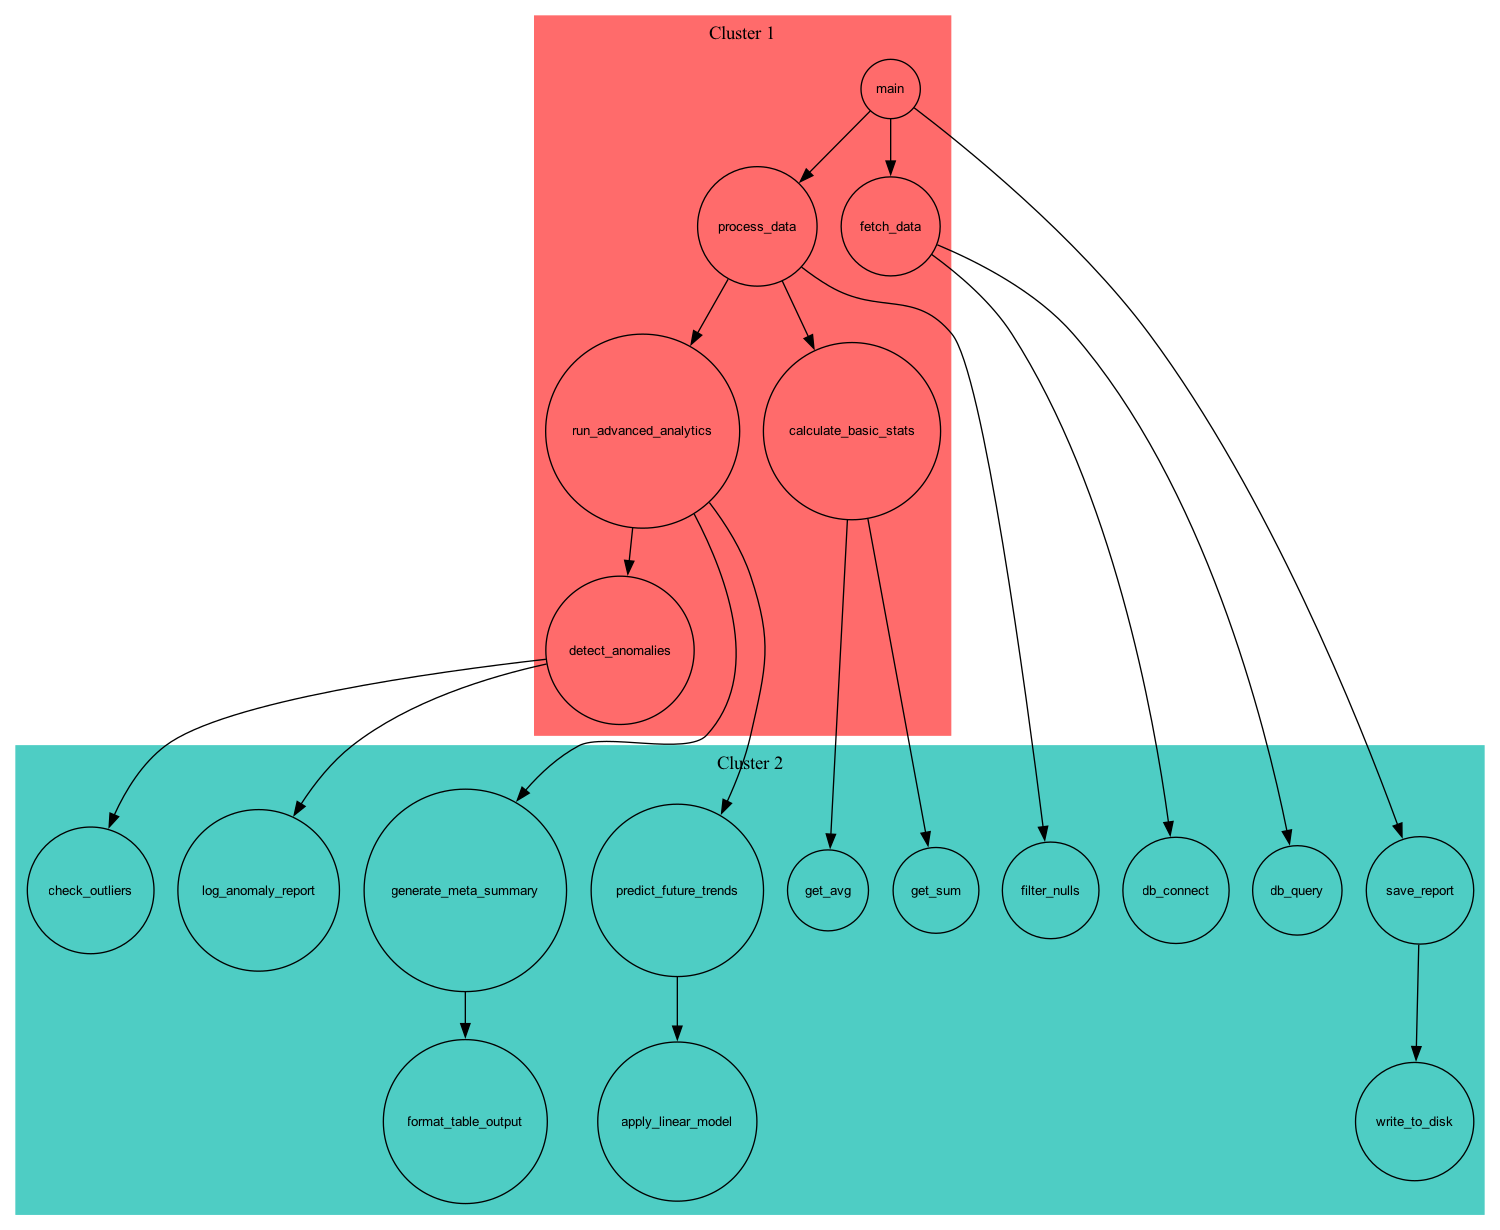


18  18 — E: Q_INOUT=2.0          {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 18: 18 — E: Q_INOUT=2.0
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


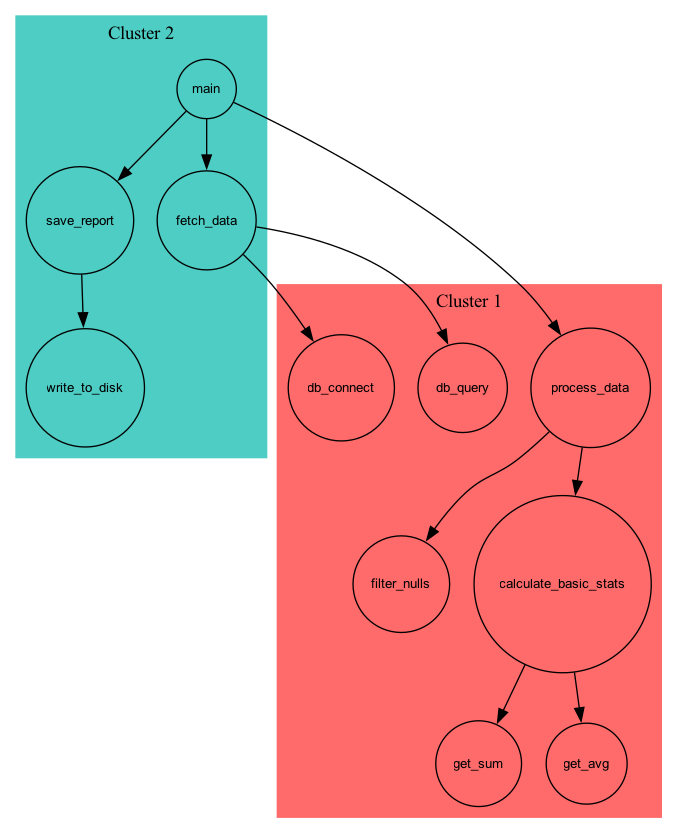

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


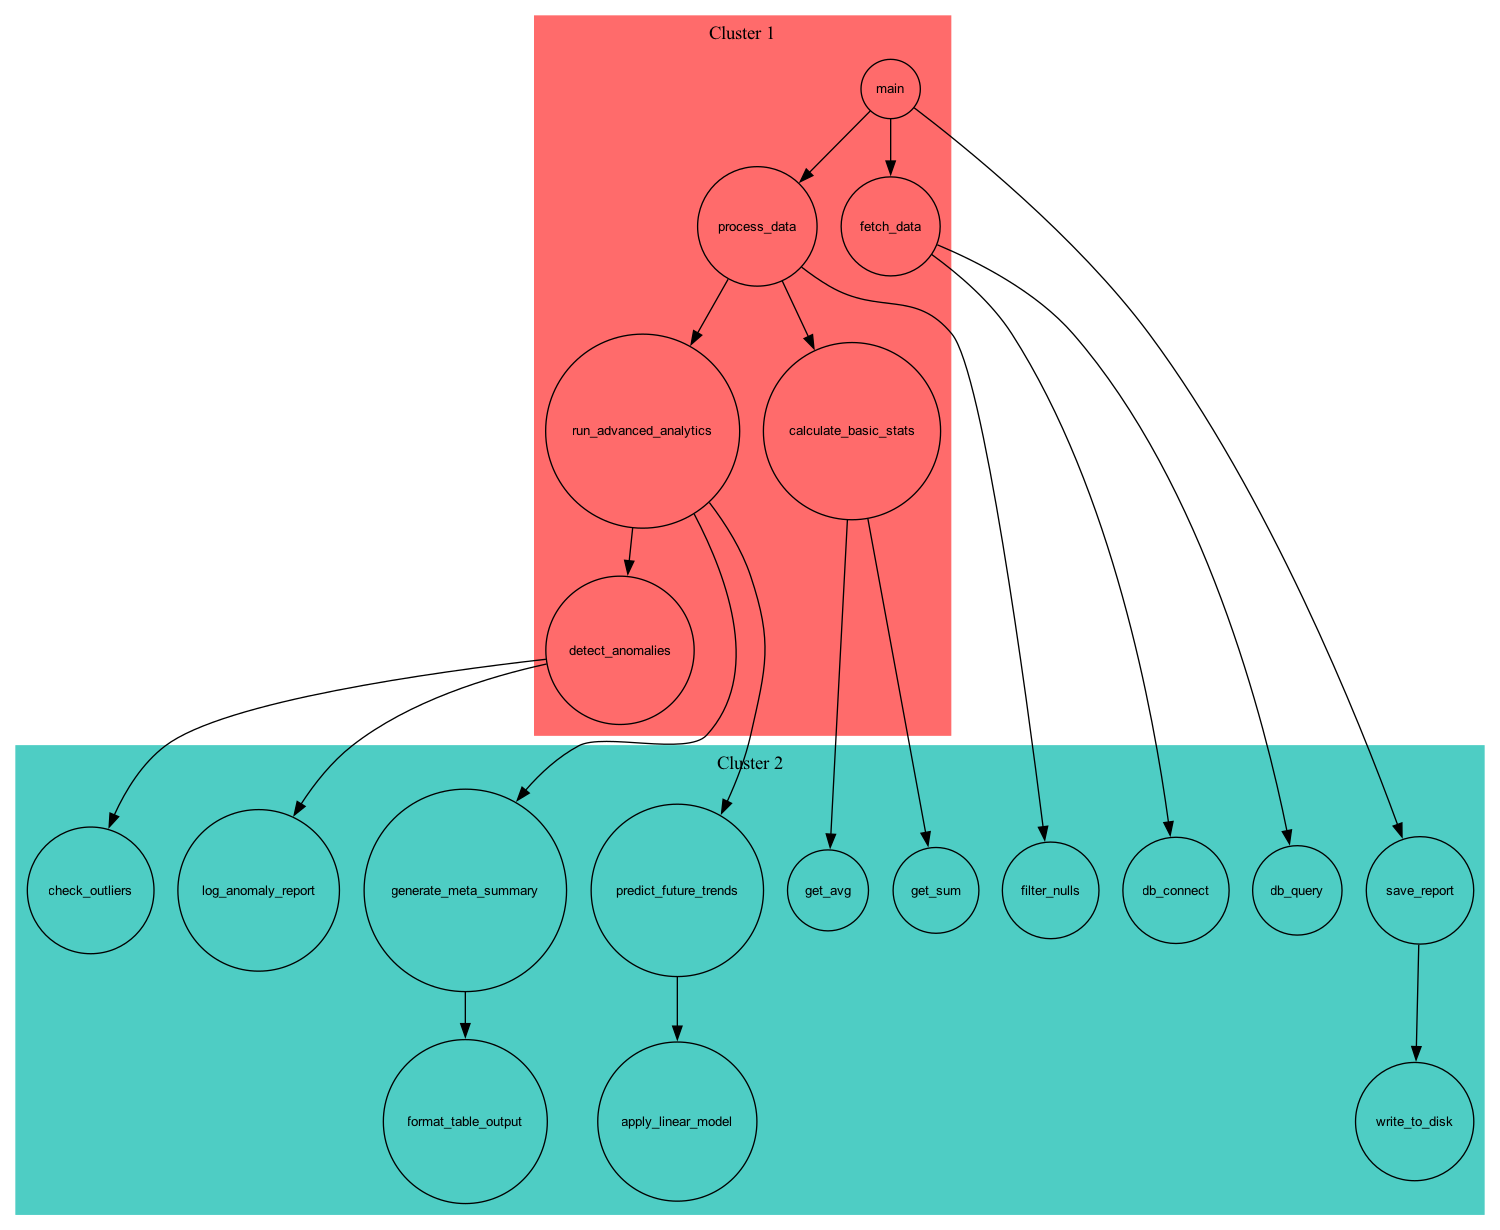


19  19 — E: Q_INOUT=4.0          {2: ['fetch_data', 'main', 'save_report', 'write_to_disk'], 1: ['calculate_basic_stats', 'db_connect', 'db_query', 'filter_nulls', 'get_avg', 'get_sum', 'process_data']} {1: ['calculate_basic_stats', 'detect_anomalies', 'fetch_data', 'main', 'process_data', 'run_advanced_analytics'], 2: ['apply_linear_model', 'check_outliers', 'db_connect', 'db_query', 'filter_nulls', 'format_table_output', 'generate_meta_summary', 'get_avg', 'get_sum', 'log_anomaly_report', 'predict_future_trends', 'save_report', 'write_to_disk']}     0.845104     1.037413

  ▶ Eksperimen 19: 19 — E: Q_INOUT=4.0
    [t0] Clusters: {1: ['db_connect', 'db_query', 'process_data', 'filter_nulls', 'calculate_basic_stats', 'get_sum', 'get_avg'], 2: ['main', 'fetch_data', 'save_report', 'write_to_disk']}


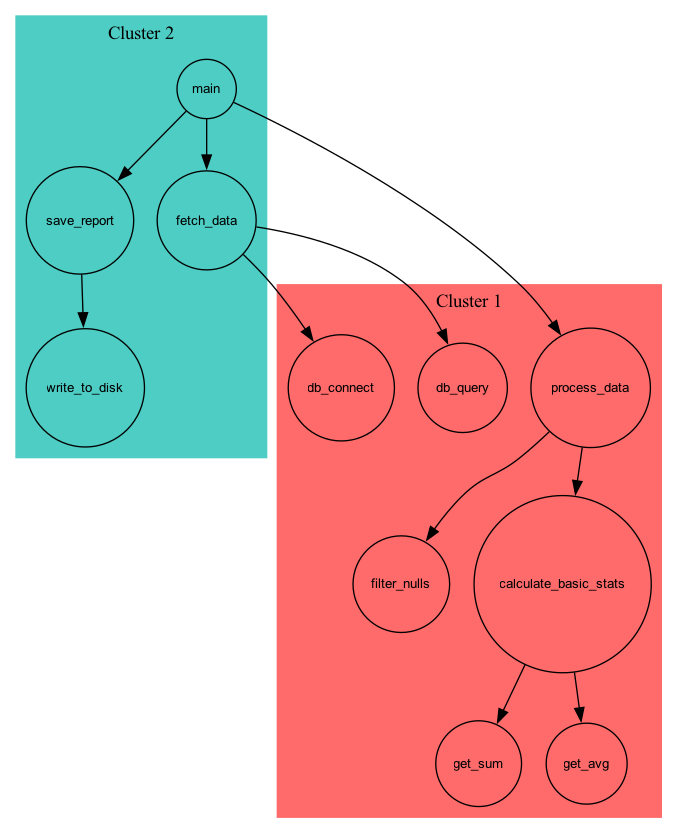

    [t1] Clusters: {1: ['main', 'fetch_data', 'process_data', 'run_advanced_analytics', 'detect_anomalies', 'calculate_basic_stats'], 2: ['db_connect', 'db_query', 'check_outliers', 'log_anomaly_report', 'predict_future_trends', 'apply_linear_model', 'generate_meta_summary', 'format_table_output', 'filter_nulls', 'get_sum', 'get_avg', 'save_report', 'write_to_disk']}


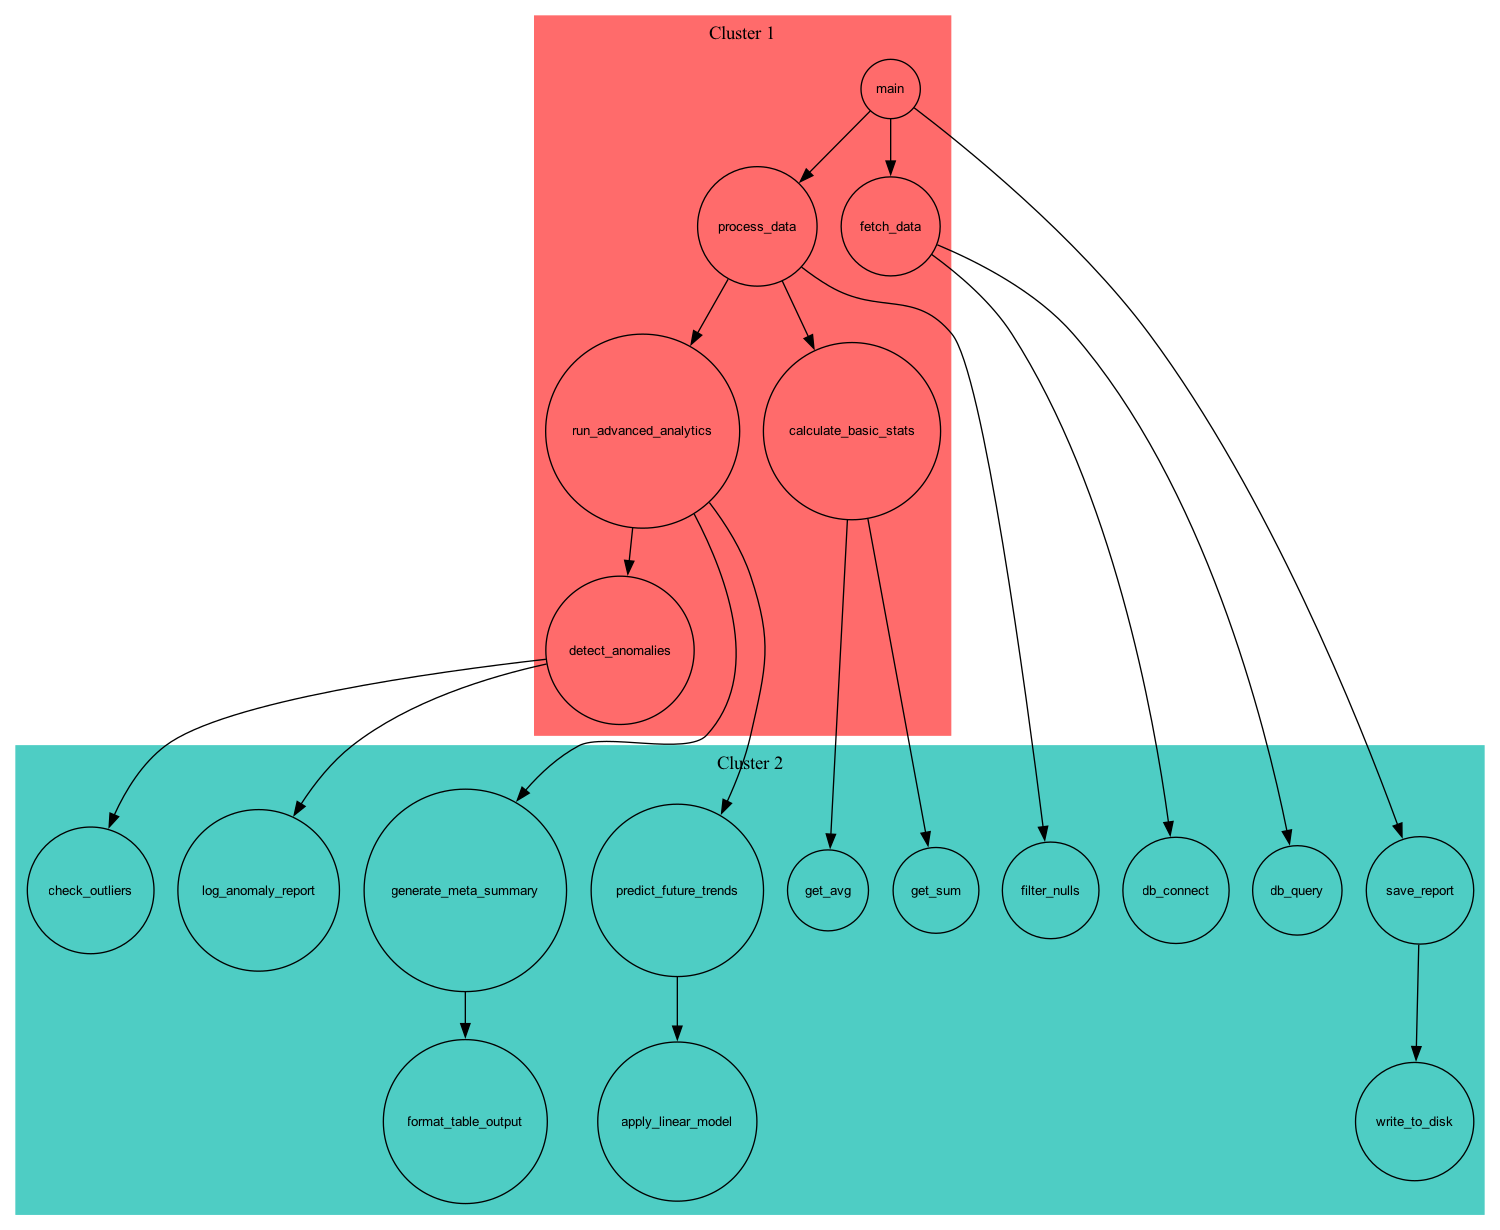



Selesai — semua 19 eksperimen selesai dijalankan.


In [29]:
# ============================================================
# OFAT — 19 Eksperimen Isolasi Parameter Node2Vec
# ============================================================

import itertools

# Baseline
BASE = dict(
    EMBED_DIM   = 4,
    WALK_LENGTH = 10,
    NUM_WALKS   = 200,
    P_RETURN    = 1.0,
    Q_INOUT     = 1.0,
)

# Daftar 19 eksperimen
experiments = [
    # No | kelompok | perubahan
    { **BASE, "label": "01 — Baseline" },

    # A — EMBED_DIM
    { **BASE, "EMBED_DIM":  2, "label": "02 — A: EMBED_DIM=2" },
    { **BASE, "EMBED_DIM":  8, "label": "03 — A: EMBED_DIM=8" },
    { **BASE, "EMBED_DIM": 16, "label": "04 — A: EMBED_DIM=16" },

    # B — WALK_LENGTH
    { **BASE, "WALK_LENGTH":  5, "label": "05 — B: WALK_LENGTH=5" },
    { **BASE, "WALK_LENGTH": 20, "label": "06 — B: WALK_LENGTH=20" },
    { **BASE, "WALK_LENGTH": 40, "label": "07 — B: WALK_LENGTH=40" },

    # C — NUM_WALKS
    { **BASE, "NUM_WALKS":  10, "label": "08 — C: NUM_WALKS=10" },
    { **BASE, "NUM_WALKS":  50, "label": "09 — C: NUM_WALKS=50" },
    { **BASE, "NUM_WALKS": 100, "label": "10 — C: NUM_WALKS=100" },
    { **BASE, "NUM_WALKS": 500, "label": "11 — C: NUM_WALKS=500" },

    # D — P_RETURN
    { **BASE, "P_RETURN": 0.25, "label": "12 — D: P_RETURN=0.25" },
    { **BASE, "P_RETURN": 0.5,  "label": "13 — D: P_RETURN=0.5" },
    { **BASE, "P_RETURN": 2.0,  "label": "14 — D: P_RETURN=2.0" },
    { **BASE, "P_RETURN": 4.0,  "label": "15 — D: P_RETURN=4.0" },

    # E — Q_INOUT
    { **BASE, "Q_INOUT": 0.25, "label": "16 — E: Q_INOUT=0.25" },
    { **BASE, "Q_INOUT": 0.5,  "label": "17 — E: Q_INOUT=0.5" },
    { **BASE, "Q_INOUT": 2.0,  "label": "18 — E: Q_INOUT=2.0" },
    { **BASE, "Q_INOUT": 4.0,  "label": "19 — E: Q_INOUT=4.0" },
]

# ── Helper: jalankan satu run pipeline ──────────────────────────────────
def run_pipeline(G, paths, f_star, cfg, k, seed=42):
    """
    Jalankan node2vec → normalisasi → fusion → clustering.
    Return: clusters, nodes, dist_matrix
    """
    e, _, _ = compute_directed_node2vec_embedding(
        G,
        dimensions  = cfg["EMBED_DIM"],
        walk_length = cfg["WALK_LENGTH"],
        num_walks   = cfg["NUM_WALKS"],
        p           = cfg["P_RETURN"],
        q           = cfg["Q_INOUT"],
        seed        = seed,
    )
    e_norm = normalize_e_l2(e)
    x = fuse_features(e_norm, f_star, alpha=1.0, beta=1.0)
    nodes, dist = compute_distance_matrix(x)
    clusters, _ = ward_clustering(x, k=k)
    return clusters, nodes, dist

# ── Helper: rata-rata jarak intra-cluster ────────────────────────────────
def mean_intra_cluster_dist(clusters, nodes, dist):
    """
    Rata-rata jarak Euclidean antar node dalam cluster yang sama.
    Makin kecil = cluster makin kompak.
    """
    node_idx = {n: i for i, n in enumerate(nodes)}
    dists = []
    for members in clusters.values():
        idxs = [node_idx[n] for n in members if n in node_idx]
        for ii in range(len(idxs)):
            for jj in range(ii + 1, len(idxs)):
                dists.append(dist[idxs[ii]][idxs[jj]])
    return float(np.mean(dists)) if dists else 0.0

# ── Loop utama ───────────────────────────────────────────────────────────
results_exp = []

print(f"{'No':<3} {'Label':<28} {'Clusters t0':<35} {'Clusters t1':<35} {'IntraDist t0':>12} {'IntraDist t1':>12}")
print("-" * 130)

for i, cfg in enumerate(experiments, 1):
    label = cfg["label"]

    # ── Jalankan pipeline ──
    c_t0, nodes_t0_exp, dist_t0_exp = run_pipeline(
        G_t0, paths_t0, f_star_t0, cfg, k=K_CLUSTERS, seed=SEED
    )
    c_t1, nodes_t1_exp, dist_t1_exp = run_pipeline(
        G_t1, paths_t1, f_star_t1, cfg, k=K_CLUSTERS, seed=SEED
    )

    intra_t0 = mean_intra_cluster_dist(c_t0, nodes_t0_exp, dist_t0_exp)
    intra_t1 = mean_intra_cluster_dist(c_t1, nodes_t1_exp, dist_t1_exp)

    row = {
        "no":           i,
        "label":        label,
        "EMBED_DIM":    cfg["EMBED_DIM"],
        "WALK_LENGTH":  cfg["WALK_LENGTH"],
        "NUM_WALKS":    cfg["NUM_WALKS"],
        "P_RETURN":     cfg["P_RETURN"],
        "Q_INOUT":      cfg["Q_INOUT"],
        "clusters_t0":  {k: sorted(v) for k, v in c_t0.items()},
        "clusters_t1":  {k: sorted(v) for k, v in c_t1.items()},
        "intra_dist_t0": round(intra_t0, 6),
        "intra_dist_t1": round(intra_t1, 6),
    }
    results_exp.append(row)

    print(f"{i:<3} {label:<28} {str(row['clusters_t0']):<35} {str(row['clusters_t1']):<35} {intra_t0:>12.6f} {intra_t1:>12.6f}")

    # ── Visualisasi summary graph per eksperimen ──
    print(f"\n  ▶ Eksperimen {i}: {label}")

    # Bangun node_to_cluster mapping untuk t0 dan t1
    n2c_t0_exp = {n: cid for cid, members in c_t0.items() for n in members}
    n2c_t1_exp = {n: cid for cid, members in c_t1.items() for n in members}

    # Summary graph (cluster-only view) untuk t0
    S_t0_exp, _ = build_summary_graph(G_t0, c_t0)
    print(f"    [t0] Clusters: {dict(sorted(c_t0.items()))}")
    show_graph_with_clusters(
        G_t0, n2c_t0_exp, c_t0,
        f"exp{i:02d}_summary_t0",
        f"Exp {i} — t0 — {label}"
    )

    # Summary graph (cluster-only view) untuk t1
    S_t1_exp, _ = build_summary_graph(G_t1, c_t1)
    print(f"    [t1] Clusters: {dict(sorted(c_t1.items()))}")
    show_graph_with_clusters(
        G_t1, n2c_t1_exp, c_t1,
        f"exp{i:02d}_summary_t1",
        f"Exp {i} — t1 — {label}"
    )

    print()

print("\nSelesai — semua 19 eksperimen selesai dijalankan.")


## Tabel Ringkasan Hasil 19 Eksperimen


In [30]:
df_exp = pd.DataFrame([
    {
        "No":          r["no"],
        "Label":       r["label"],
        "EMBED_DIM":   r["EMBED_DIM"],
        "WALK_LENGTH": r["WALK_LENGTH"],
        "NUM_WALKS":   r["NUM_WALKS"],
        "P_RETURN":    r["P_RETURN"],
        "Q_INOUT":     r["Q_INOUT"],
        "Clusters t0": str(r["clusters_t0"]),
        "Clusters t1": str(r["clusters_t1"]),
        "IntraDist t0": r["intra_dist_t0"],
        "IntraDist t1": r["intra_dist_t1"],
    }
    for r in results_exp
])

display(df_exp)

# Export ke CSV
df_exp.to_csv("hasil_19_eksperimen.csv", index=False)
print("Saved: hasil_19_eksperimen.csv")


,No,Label,EMBED_DIM,WALK_LENGTH,NUM_WALKS,P_RETURN,Q_INOUT,Clusters t0,Clusters t1,IntraDist t0,IntraDist t1
0,1,01 — Baseline,4,10,200,1.00,1.00,"{2: ['fetch_data', 'main', 'save_report', 'wri...","{1: ['calculate_basic_stats', 'detect_anomalie...",0.845104,1.037413
1,2,02 — A: EMBED_DIM=2,2,10,200,1.00,1.00,"{2: ['calculate_basic_stats', 'fetch_data', 'm...","{2: ['apply_linear_model', 'calculate_basic_st...",0.618123,0.764839
2,3,03 — A: EMBED_DIM=8,8,10,200,1.00,1.00,"{2: ['calculate_basic_stats', 'fetch_data', 'm...","{2: ['calculate_basic_stats', 'db_connect', 'd...",0.958911,1.160070
3,4,04 — A: EMBED_DIM=16,16,10,200,1.00,1.00,"{2: ['db_connect', 'db_query', 'fetch_data', '...","{1: ['calculate_basic_stats', 'detect_anomalie...",0.979498,1.183443
4,5,05 — B: WALK_LENGTH=5,4,5,200,1.00,1.00,"{2: ['fetch_data', 'main', 'save_report', 'wri...","{1: ['calculate_basic_stats', 'detect_anomalie...",0.845104,1.037413
5,6,06 — B: WALK_LENGTH=20,4,20,200,1.00,1.00,"{2: ['fetch_data', 'main', 'save_report', 'wri...","{1: ['calculate_basic_stats', 'detect_anomalie...",0.845104,1.037413
6,7,07 — B: WALK_LENGTH=40,4,40,200,1.00,1.00,"{2: ['fetch_data', 'main', 'save_report', 'wri...","{1: ['calculate_basic_stats', 'detect_anomalie...",0.845104,1.037413
7,8,08 — C: NUM_WALKS=10,4,10,10,1.00,1.00,"{2: ['calculate_basic_stats', 'db_query', 'mai...","{2: ['calculate_basic_stats', 'db_query', 'det...",1.377005,1.314739
8,9,09 — C: NUM_WALKS=50,4,10,50,1.00,1.00,"{2: ['db_connect', 'filter_nulls', 'main', 'pr...","{2: ['calculate_basic_stats', 'detect_anomalie...",1.085544,0.662362
9,10,10 — C: NUM_WALKS=100,4,10,100,1.00,1.00,"{2: ['calculate_basic_stats', 'fetch_data', 'm...","{1: ['db_connect', 'db_query', 'fetch_data', '...",0.656859,1.008148


Saved: hasil_19_eksperimen.csv
